In [1]:
import os
import sys
sys.path.append(os.path.expanduser('~'))
import numpy as np 
from matplotlib import pyplot as plt
from datetime import datetime as dt
import figures as fgs
from albatros_analysis.src.correlations import baseband_data_classes as bdc
from albatros_analysis.src.utils import baseband_utils as butils
from albatros_analysis.src.utils import orbcomm_utils as outils
import numba as nb
import time
import importlib
import json
from scipy.optimize import minimize
from skyfield.api import load, wgs84
import cupy
import offset_helper as oh
#from pyuvdata import UVData

BDC is using numpy
BDC is using numpy


In [2]:
@nb.njit(parallel=True)
def apply_delay(arr, out, delay, freqs):
    # apply delay to an array of complex electric field or their correlation
    # does exp( j 2 pi nu tau) sign of tau is user dependent
    # freqs should correspond to the columns of the nspec x nchan array
    nspec = arr.shape[0]
    nchan = arr.shape[1]
    for i in nb.prange(nspec):
        for j in range(nchan):
            out[i, j] = arr[i, j] * np.exp(2j * np.pi * freqs[j] * delay[i])
    return out

@nb.njit(parallel=True)
def apply_delay_1d(arr, out, delay, freq):
    # apply delay to an array of complex electric field or their correlation
    # does exp( j 2 pi nu tau) sign of tau is user dependent
    # freqs should correspond to the columns of the nspec x nchan array
    nspec = arr.shape[0]
    for i in nb.prange(nspec):
            out[i] = arr[i] * np.exp(2j * np.pi * freq * delay[i])
    return out

@nb.njit(parallel=True)
def xcorr_avg(arr1,arr2,acclen):
    #helper function
    nblocks = arr1.shape[0]//acclen
    nchan = arr1.shape[1]
    out = np.zeros((nblocks,nchan),dtype=arr1.dtype)
    for i in nb.prange(nblocks):
        for j in range(acclen):
            for k in range(nchan):
                out[i,k] += arr1[i*acclen + j,k]*np.conj(arr2[i*acclen + j,k])
        out[i,:]/=acclen
    return out

@nb.njit(parallel=True)
def xcorr_avg_1d(arr1,arr2,acclen):
    #helper function
    nblocks = arr1.shape[0]//acclen
    out = np.zeros((nblocks,),dtype=arr1.dtype)
    for i in nb.prange(nblocks):
        for j in range(acclen):
                out[i] += arr1[i*acclen + j]*np.conj(arr2[i*acclen + j])
        out[i]/=acclen
    return out
    

def haversine(p1, p2, radius=6371000):
    """
    Vectorized Haversine distance using NumPy.

    Parameters
    ----------
    p1 : array-like of shape (..., 2)
        lat, lon in degrees
    p2 : array-like of shape (..., 2)
        lat, lon in degrees
    radius : float
        Earth radius (km by default)

    Returns
    -------
    distances : ndarray
        Distance(s) in the same unit as `radius`.
    """
    p1 = np.asarray(p1, dtype=float)
    p2 = np.asarray(p2, dtype=float)

    lat1 = np.radians(p1[..., 0])
    lon1 = np.radians(p1[..., 1])
    lat2 = np.radians(p2[..., 0])
    lon2 = np.radians(p2[..., 1])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return radius * c

In [3]:
config_path = '/home/thomasb/albatros_analysis/scripts/xcorr/config/config_bright_test.json'
disk_path = '/scratch/thomasb/raw_1753216650:1753217000_bit=1_ant=7_pol=2_cha=1834:1852_tim=650_upx=64_acc=512_ipfb=0.4_complex64_regular_20260110T114008.npy'

config_path2 = '/home/thomasb/albatros_analysis/scripts/xcorr/config/config_bright_test2.json'
disk_path2 = '/scratch/thomasb/raw_1753221865:1753222245_bit=1_ant=7_pol=2_cha=1834:1852_tim=706_upx=64_acc=512_ipfb=0.4_complex64_regular_20260106T105646.npy'

config_path3 = '/home/thomasb/albatros_analysis/scripts/xcorr/config/config_bright_test3.json'
disk_path3 = '/scratch/thomasb/raw_1753236330:1753236730_bit=1_ant=7_pol=2_cha=1834:1852_tim=744_upx=64_acc=512_ipfb=0.4_complex64_regular_20260106T220616.npy'

config_path4 = '/home/thomasb/albatros_analysis/scripts/xcorr/config/config_bright_test4.json'
disk_path4 = '/scratch/thomasb/raw_1753216650:1753217000_bit=1_ant=7_pol=2_cha=1834:1852_tim=650_upx=64_acc=512_ipfb=0.4_complex64_regular_20260107T185223.npy'

In [4]:
#open config and get metadata
with open(config_path, "r") as f:
    config = json.load(f)
ant_names, ant_coords, dir_parents, spec_offsets = [], [], [], []
# Call get_starting_index for all antennas except reference
for i, (ant, details) in enumerate(config["antennas"].items()):
    dir_parents.append(details["path"])
    spec_offsets.append(details["clock_offset"])
    ant_names.append(details["name"])
    ant_coords.append(details["coordinates"])

ant_numbers = np.array([int(name.split()[1]) for name in ant_names])
batch_start_ts = config["correlation"]["start_timestamp"]
batch_end_ts = config["correlation"]["end_timestamp"]
chanstart = config["frequency"]["start_channel"]
chanend = config["frequency"]["end_channel"]
osamp = config["correlation"]["osamp"]
pfb_size = config["correlation"]["pfb_size"]
new_acclen = config["correlation"]["new_acclen"]

new_chunk_len = (new_acclen*4096*osamp)/250e6
tle_path = outils.get_tle_file(batch_start_ts, "/project/rrg-sievers/mohanagr/OCOMM_TLES")
print(new_acclen)
print(batch_start_ts)
print(batch_end_ts)

512
1753216650
1753217000


In [5]:
data_all = np.load(disk_path)

In [6]:
data_all.shape

(7, 2, 332800, 1152)

In [12]:
#-------------test case info--------

satID = 57166

#-------------------------------------

acclen=1024
bb_spectrum_T = 4096/250e6
osamp = 64
T_SPECTRA = bb_spectrum_T * osamp
nchans = data_all.shape[3]
sat_freqs = 250e6 - ((np.arange(nchans)/osamp + 1834)/(4096/250e6))

print(nchans)
print(sat_freqs.shape)
print(sat_freqs[0])
print(T_SPECTRA)

1152
(1152,)
138061523.4375
0.001048576


In [13]:
files, idx = butils.get_init_info(batch_start_ts, batch_end_ts, dir_parents[0])
print(idx)
print(files)
pulse = bdc.BasebandFileIterator(
        files,
        0,
        idx,
        acclen,
        None,
        chanstart=1834,
        chanend=1852,
        type="float",
    )

start_specnum = pulse.spec_num_start
print(start_specnum)

spec_offset = (1326718046 - 1008319099)
print(spec_offset)

time_distance = 1753221865 - 1753216650
print(time_distance)
print(time_distance * 250e6/4096)
print(spec_offset)
print(int(time_distance * 250e6/4096) - spec_offset)

# so we should introduce an artificial specnum offset when loading up all antenna!

#looks reasonable
t2 = 1753221865 + 0.3371875
t1 = 1753216650 -1.28
print(t2-t1)
print(spec_offset * 4096/250e6)

671387
['/scratch/mohanagr/summer_2025/baseband/mars1/17532/1753216639.raw', '/scratch/mohanagr/summer_2025/baseband/mars1/17532/1753216692.raw', '/scratch/mohanagr/summer_2025/baseband/mars1/17532/1753216744.raw', '/scratch/mohanagr/summer_2025/baseband/mars1/17532/1753216798.raw', '/scratch/mohanagr/summer_2025/baseband/mars1/17532/1753216853.raw', '/scratch/mohanagr/summer_2025/baseband/mars1/17532/1753216906.raw', '/scratch/mohanagr/summer_2025/baseband/mars1/17532/1753216960.raw']
ACCLEN RECEIVED IS 1024
took 0.531 seconds to read raw data on  /scratch/mohanagr/summer_2025/baseband/mars1/17532/1753216639.raw
START SPECNUM IS 1008319099 obj start at 1007647712
1008319099
318398947
5215
318298339.84375
318398947
-100608
5216.6171875
5216.648347648


In [14]:
def beamformed_xcorr(data, ant1_idx, ant2_idx, pol1_idx, pol2_idx, delay, freqs, acclen):
    nants, npols, nspec, nchans = data.shape
    assert len(freqs) == nchans
    assert len(delay) == nspec
    spec1=data[ant1_idx,pol1_idx,:,:].copy()
    spec2=data[ant2_idx,pol2_idx,:,:].copy()
    spec2_phased = np.empty_like(spec2)
    spec2_phased = apply_delay(spec2, spec2_phased, -delay, freqs)
    V = xcorr_avg(spec1,spec2_phased,acclen)
    return V

In [15]:
def efield_to_vis(
    data_all,
    t_start,
    t_end,
    ant1_idx,
    ant2_idx,
    pol1_idx,
    pol2_idx,
    ant_coords,
    satID,
    sat_freqs,
    acclen = 1024,
    osamp = 64,
    bb_spectrum_T = 4096/250e6
):

    """ 
    Notes: require t_start to coincide with the first spectrum of data_all.
    As long as t_end is after the last spectrum, the interpolation is fine.
    """
    T_SPECTRA = bb_spectrum_T * osamp
    nspec = int((t_end - t_start)/T_SPECTRA)
    print(nspec)
    data_all = data_all[:, :, :nspec, :]
    print(data_all.shape)
    ant1_coords = ant_coords[ant1_idx]
    ant2_coords = ant_coords[ant2_idx]
    tle_path = outils.get_tle_file(t_start, "/project/rrg-sievers/mohanagr/OCOMM_TLES")
    sats_objects = load.tle_file(tle_path)

    dly = outils.get_sat_delay2(
                        ant1_coords,
                        ant2_coords,
                        sats_objects,
                        t_start,
                        int(t_end-t_start)+1,
                        satID,
                        altaz=False
                    )
    print(dly.shape)

    delay = np.interp(np.arange(0, nspec) * T_SPECTRA, np.arange(0, int(t_end-t_start)+1), dly)
    print(delay.shape)

    Vxx = beamformed_xcorr(data_all, ant1_idx, ant2_idx, 0, 0, delay, sat_freqs, acclen)
    Vyy = beamformed_xcorr(data_all, ant1_idx, ant2_idx, 1, 1, delay, sat_freqs, acclen)
    V=(Vxx+Vyy)/2
    return V.T

In [17]:
V = efield_to_vis(data_all[:, :, :, 100:300], batch_start_ts, batch_end_ts-2, 0, 1, 0, 0, ant_coords, satID, sat_freqs[100:300])

331878
(7, 2, 331878, 200)
(349,)
(331878,)


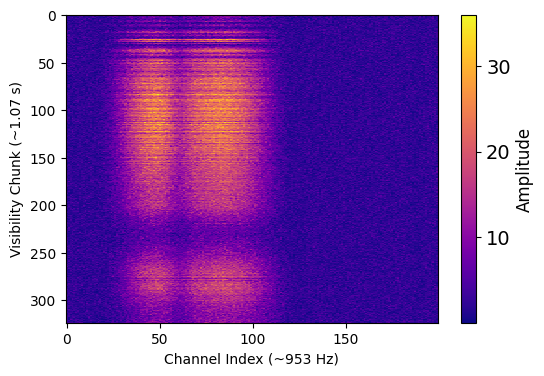

In [18]:
figure = fgs.make_ampfig(V, acclen, T_SPECTRA)

In [19]:
#----------test case info------------

chan_new = 140

#-------------------------------------

freq = sat_freqs[chan_new]
print(freq/1e6)

ant_idxs = [0, 2, 3, 4, 5, 6]

data_slice = data_all[:, :, :, chan_new].copy()
print(data_slice.shape)

137.92800903320312
(7, 2, 332800)


In [20]:
#------------test case info----------
#first one
cut_spectra_start = 60000
cut_seconds_end = 150
#second one

#third one
#----------------------------------

pulse_start_ts = batch_start_ts + T_SPECTRA* cut_spectra_start
pulse_end_ts = batch_end_ts - cut_seconds_end
data_all_cut = data_all[:, :, cut_spectra_start:, :]
data_slice_cut = data_slice[:, :, cut_spectra_start:]

130734
(7, 2, 130734, 200)
(138,)
(130734,)


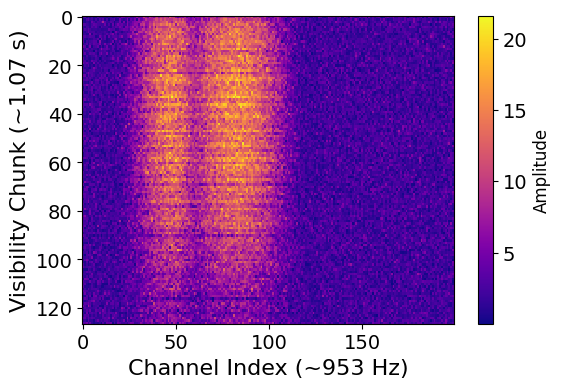

In [21]:
V = efield_to_vis(data_all_cut[:, :, :, 100:300], pulse_start_ts, pulse_end_ts, 2, 6, 0, 0, ant_coords, satID, sat_freqs[100:300])
figure = fgs.make_ampfig(V, acclen, T_SPECTRA)

In [22]:
def objective_times(time_offset,
                    t_start,
                    t_end,
                    data_slice,
                    ant_idxs,
                    ant_coords,
                    freq,
                    satID,
                    plot=False,
                    bb_spectrum_T=4096/250e6,
                    osamp=64,
                    acclen = 1024):

    """ 
    t_start needs to coincide with the first spectrum of the data.
    however, t_end will determine how much the data is cut by, so as long as it's
    BEFORE the last spectrum in the data, we're all good.

    this is done to make cutting garbage time at the end easier, and minimize interference with the data array
    """

    process_start_ts = time.time()
    #turn time_offset into float when passed in scipy.optimize.minimize
    if type(time_offset) == np.ndarray:
        time_offset = time_offset[0]

    if plot:
        fig, ax = plt.subplots(figsize=(10, 5), dpi=300)
        ax.axhline(6.28, ls='--',c='black')
        ax.axhline(-6.28,ls='--', c='black')
        plt.rcParams.update({
            "font.size": 16,
            "axes.labelsize": 18,
            "axes.titlesize": 20,
            "xtick.labelsize": 14,
            "ytick.labelsize": 14,
            "figure.titlesize": 22,
            "legend.fontsize": 14
        })

    T_SPECTRA = bb_spectrum_T * osamp
    tle_path = outils.get_tle_file(t_start, "/project/rrg-sievers/mohanagr/OCOMM_TLES")
    sats_objects = load.tle_file(tle_path)

    nspec_tot = data_slice.shape[2]
    nspec = int((t_end-t_start)/T_SPECTRA)
    print('nspec total', nspec_tot)
    print('nspec', nspec)
    data_slice = data_slice[:, :, :nspec].copy()

    assert nspec_tot > nspec
    assert (nspec*bb_spectrum_T) < (t_end-t_start+1)

    chisq = 0
    sum_wt = 0
    for i in range(len(ant_idxs)):
        for j in range(i+1, len(ant_idxs)):
            ai = ant_idxs[i]
            aj = ant_idxs[j]
            a1_coords=ant_coords[ai]
            a2_coords=ant_coords[aj]
            dist = oh.haversine(a1_coords,a2_coords)
            sum_wt += dist**2


            dly = outils.get_sat_delay2(
                                a1_coords,
                                a2_coords,
                                sats_objects,
                                t_start+time_offset,
                                int(t_end-t_start)+1,
                                satID,
                                altaz=False
                            )
            delay = np.interp(
                np.arange(0, nspec) * T_SPECTRA, np.arange(0, int(t_end-t_start)+1), dly
            )
            spec2_phased = np.empty_like(data_slice[aj,0,:])
            spec2_phased = apply_delay_1d(data_slice[aj,0,:], spec2_phased, -delay, freq)
            Vxx = xcorr_avg_1d(data_slice[ai,0,:],spec2_phased,acclen)
            spec2_phased = apply_delay_1d(data_slice[aj,1,:], spec2_phased, -delay, freq)
            Vyy = xcorr_avg_1d(data_slice[ai,1,:],spec2_phased,acclen)
            V=(Vxx+Vyy)/2


            if plot:
                ax.plot(np.unwrap(np.angle(V))-np.angle(V)[0],label=f'{ai}-{aj}')
                plt.legend()

            
            Vnew = np.exp(1j*np.angle(V))
            chisq-= dist**2*np.abs(np.mean(Vnew))**2 
    chisq/=sum_wt
    print('time for objective compute:', time.time()-process_start_ts)
    print("offset", time_offset, "chisq", chisq)

    if plot:
        ax.set_xlabel(f"Visibility Chunk(~{np.round(T_SPECTRA*acclen, decimals=2)} s)")
        ax.set_ylabel("Unwrapped Phase (radians)")
        ax.set_title(f"Phase at Baslines (offset={time_offset}, sat={satID})")
        ax.grid(True, alpha=0.3)

        ax.legend(
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            frameon=False
        )
        plt.tight_layout()
        return chisq, fig
    
    return chisq

nspec total 332800
nspec 331878
time for objective compute: 1.5095949172973633
offset 0 chisq -0.009214192187560906


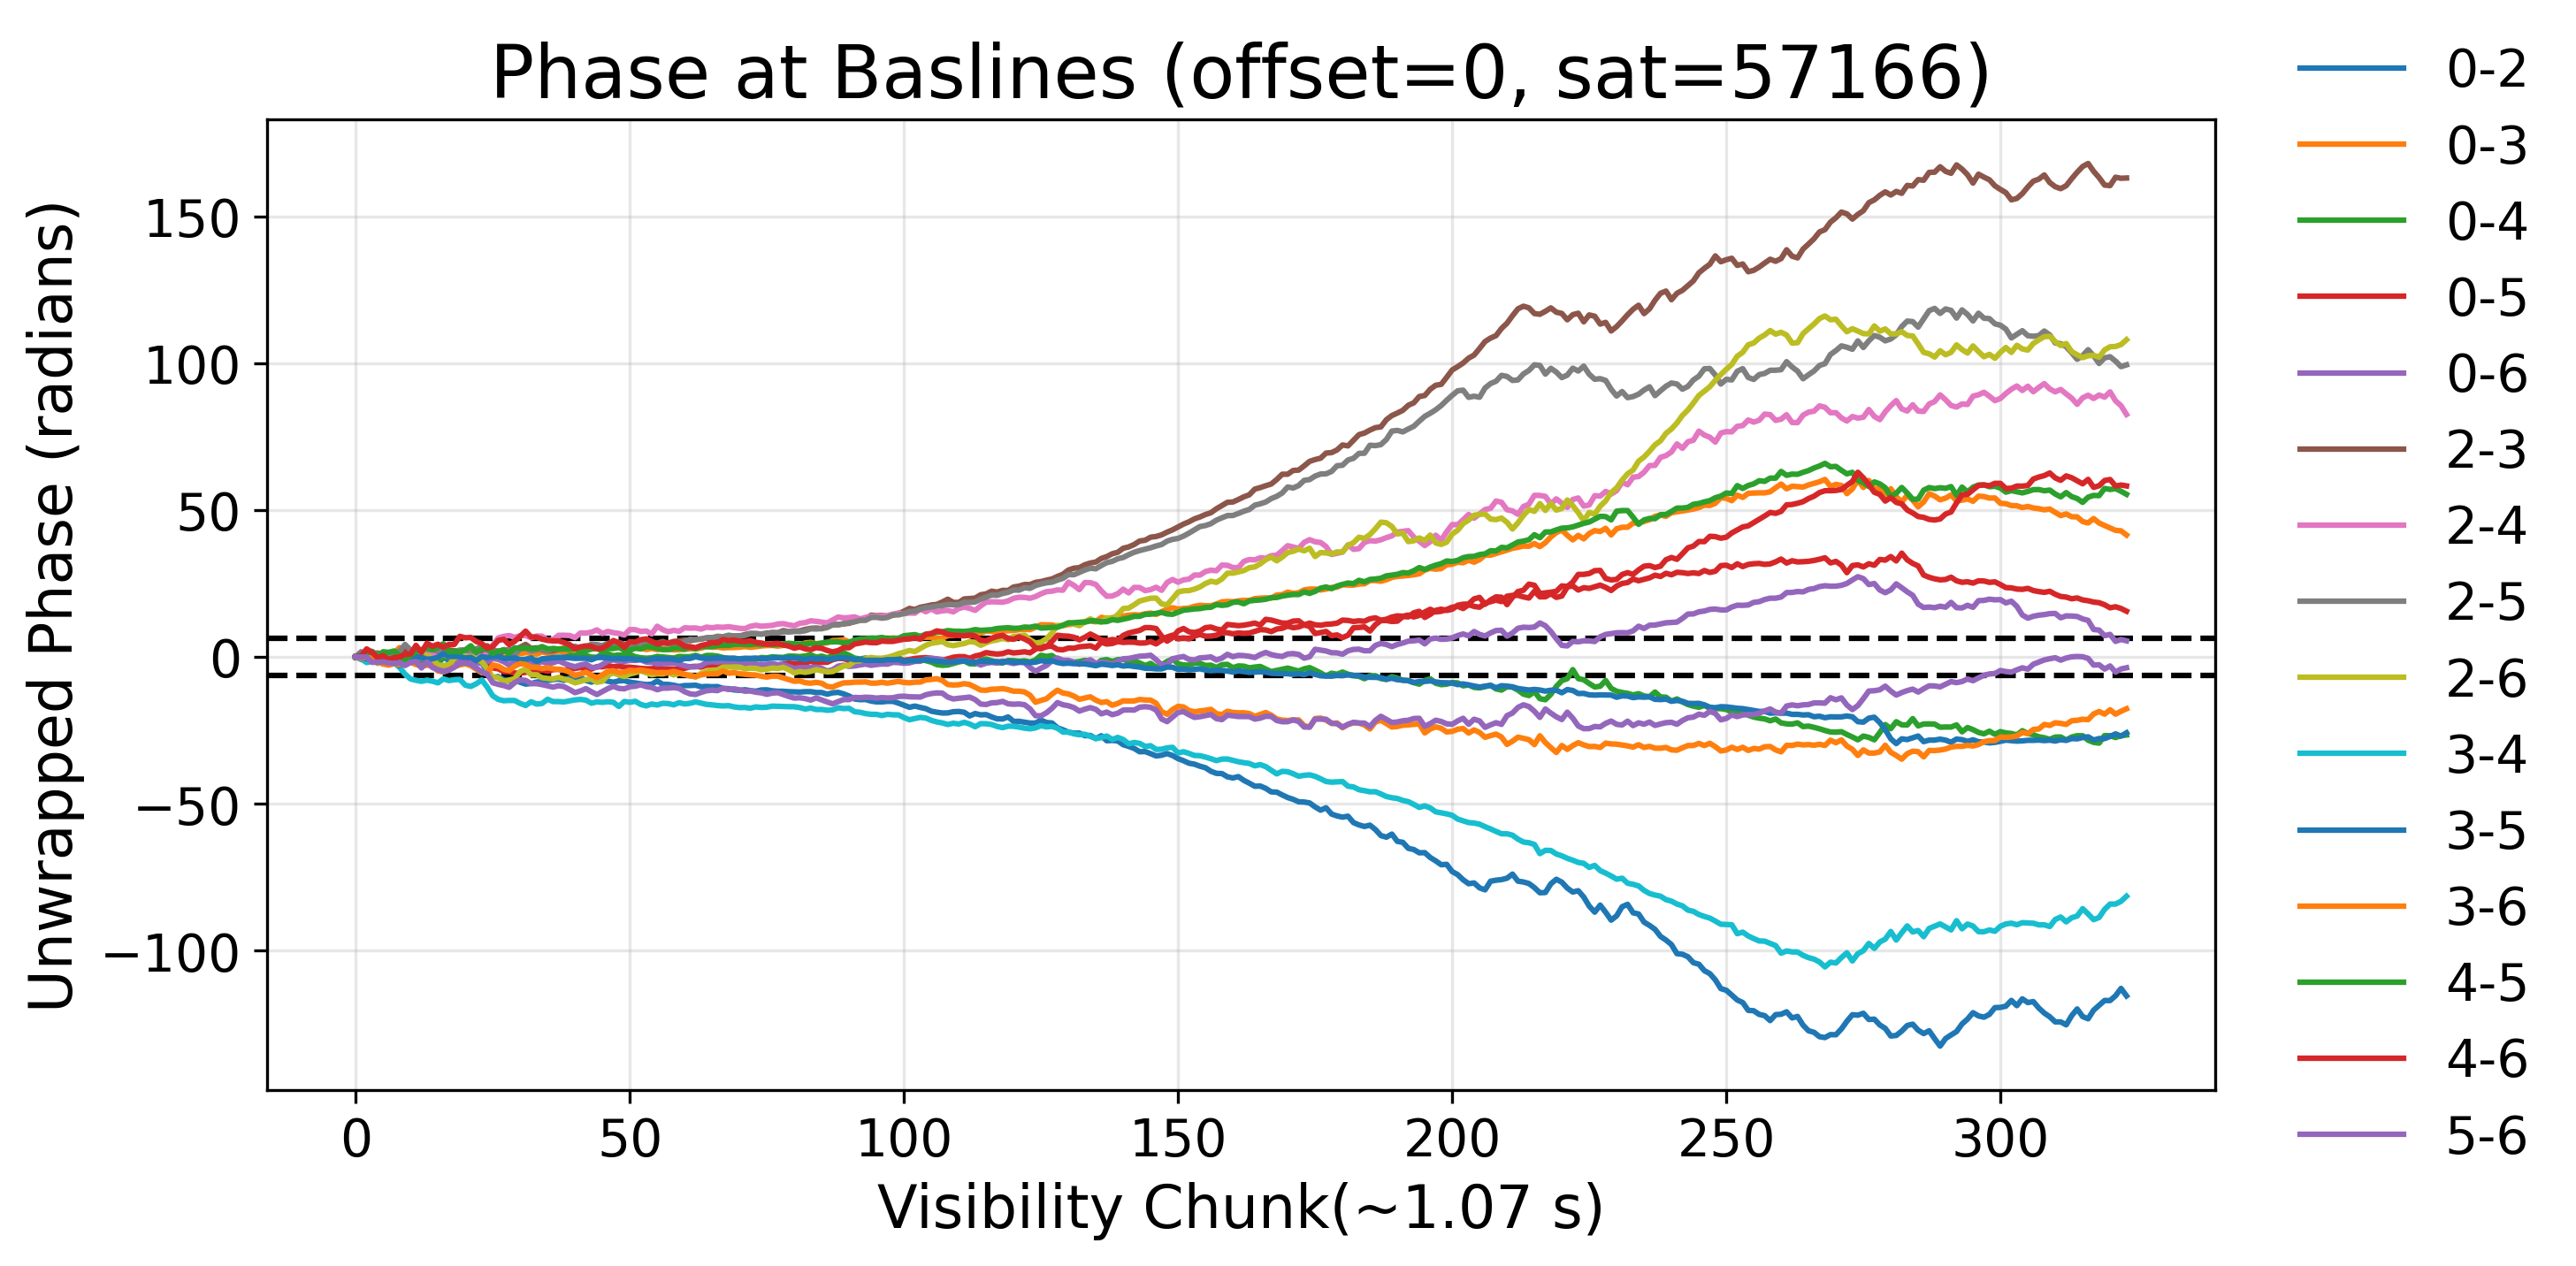

In [23]:
#once without cutting anything
chisq, fig = objective_times(0,
                        batch_start_ts,
                        batch_end_ts-2,
                        data_slice,
                        ant_idxs,
                        ant_coords,
                        freq,
                        satID,
                        plot=True)
plt.show(fig)

nspec total 272800
nspec 159345


time for objective compute: 0.7886102199554443
offset 0 chisq -0.006831506151059341


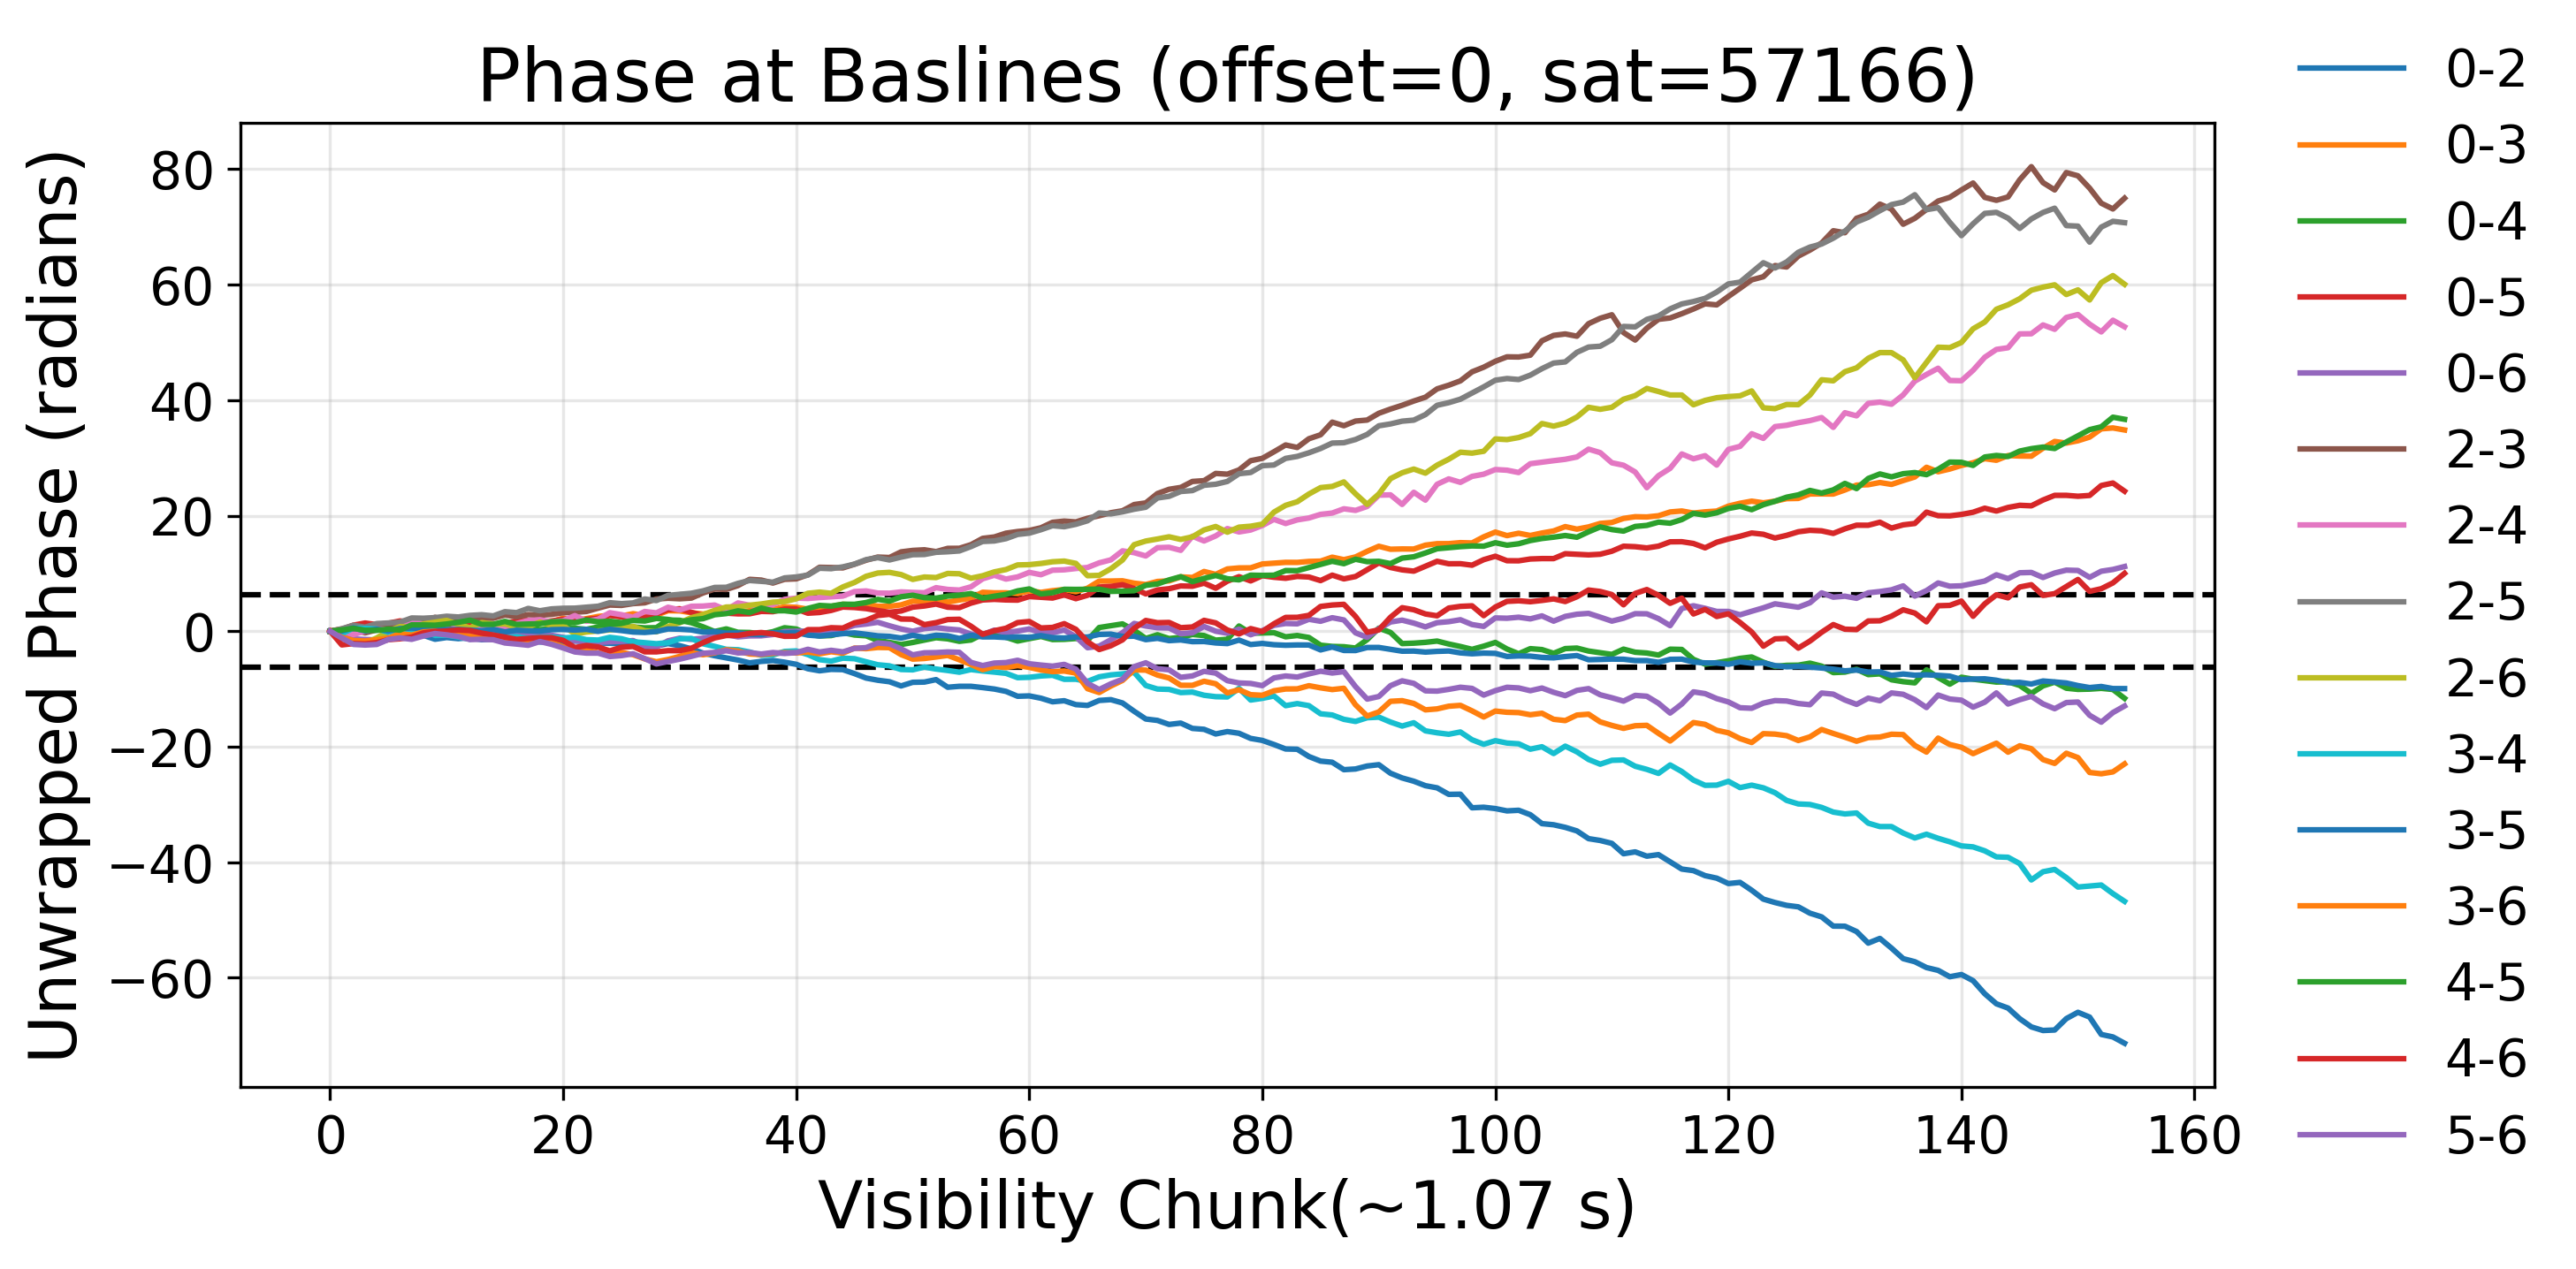

In [52]:
#once after cutting everything to make sure it actually improves
chisq = objective_times(0,
                        pulse_start_ts,
                        pulse_end_ts,
                        data_slice_cut,
                        ant_idxs,
                        ant_coords,
                        freq,
                        satID,
                        plot=True)

In [25]:
def cost_curve(
    offset_start,
    offset_end,
    ntimes,
    batch_start_ts,
    batch_end_ts,
    data_slice,
    ant_idxs,
    ant_coords,
    freq,
    satID,
    bb_spectrum_T=4096/250e6,
    osamp=64,
    include_fig=False,
    vline = None,
):
    """ 
    Generates cost curve of single pulse given time offset intervals and steps.
    """

    offsets = np.linspace(offset_start, offset_end, ntimes)
    chisqs = np.zeros(len(offsets),dtype='float64')
    for i,offset in enumerate(offsets):
        print(f'\n----ITERATION {i}-----')
        chisqs[i]=objective_times(offset,
                            batch_start_ts,
                            batch_end_ts,
                            data_slice,
                            ant_idxs,
                            ant_coords,
                            freq,
                            satID,
                            plot=False,
                            bb_spectrum_T=bb_spectrum_T,
                            osamp=osamp)
    


    if include_fig:
        fig, ax = plt.subplots(figsize=(8, 4), dpi=300)
        plt.rcParams.update({
            "font.size": 16,
            "axes.labelsize": 18,
            "axes.titlesize": 20,
            "xtick.labelsize": 14,
            "ytick.labelsize": 14,
            "figure.titlesize": 22,
            "legend.fontsize": 14
        })
        ax.plot(offsets,chisqs)
        ax.set_xlabel('Time Discrepancy (s)')
        ax.set_ylabel(r'$\chi ^2$')
        if vline:
            plt.axvline(x=vline, color='r', linestyle='--')
        return offsets, chisqs, fig

    else:
        return offsets, chisqs


----ITERATION 0-----
nspec total 332800
nspec 331878
time for objective compute: 0.8688337802886963
offset -2.0 chisq -0.011328618207595724

----ITERATION 1-----
nspec total 332800
nspec 331878
time for objective compute: 0.8733134269714355
offset -1.96 chisq -0.01092403553506955

----ITERATION 2-----
nspec total 332800
nspec 331878
time for objective compute: 0.8920679092407227
offset -1.92 chisq -0.011550340190616052

----ITERATION 3-----
nspec total 332800
nspec 331878
time for objective compute: 0.9013969898223877
offset -1.88 chisq -0.011329848406521716

----ITERATION 4-----
nspec total 332800
nspec 331878
time for objective compute: 0.625382661819458
offset -1.84 chisq -0.014761761006761673

----ITERATION 5-----
nspec total 332800
nspec 331878
time for objective compute: 0.4871695041656494
offset -1.8 chisq -0.016429195738187245

----ITERATION 6-----
nspec total 332800
nspec 331878
time for objective compute: 0.6589157581329346
offset -1.76 chisq -0.01673889975044438

----ITERAT

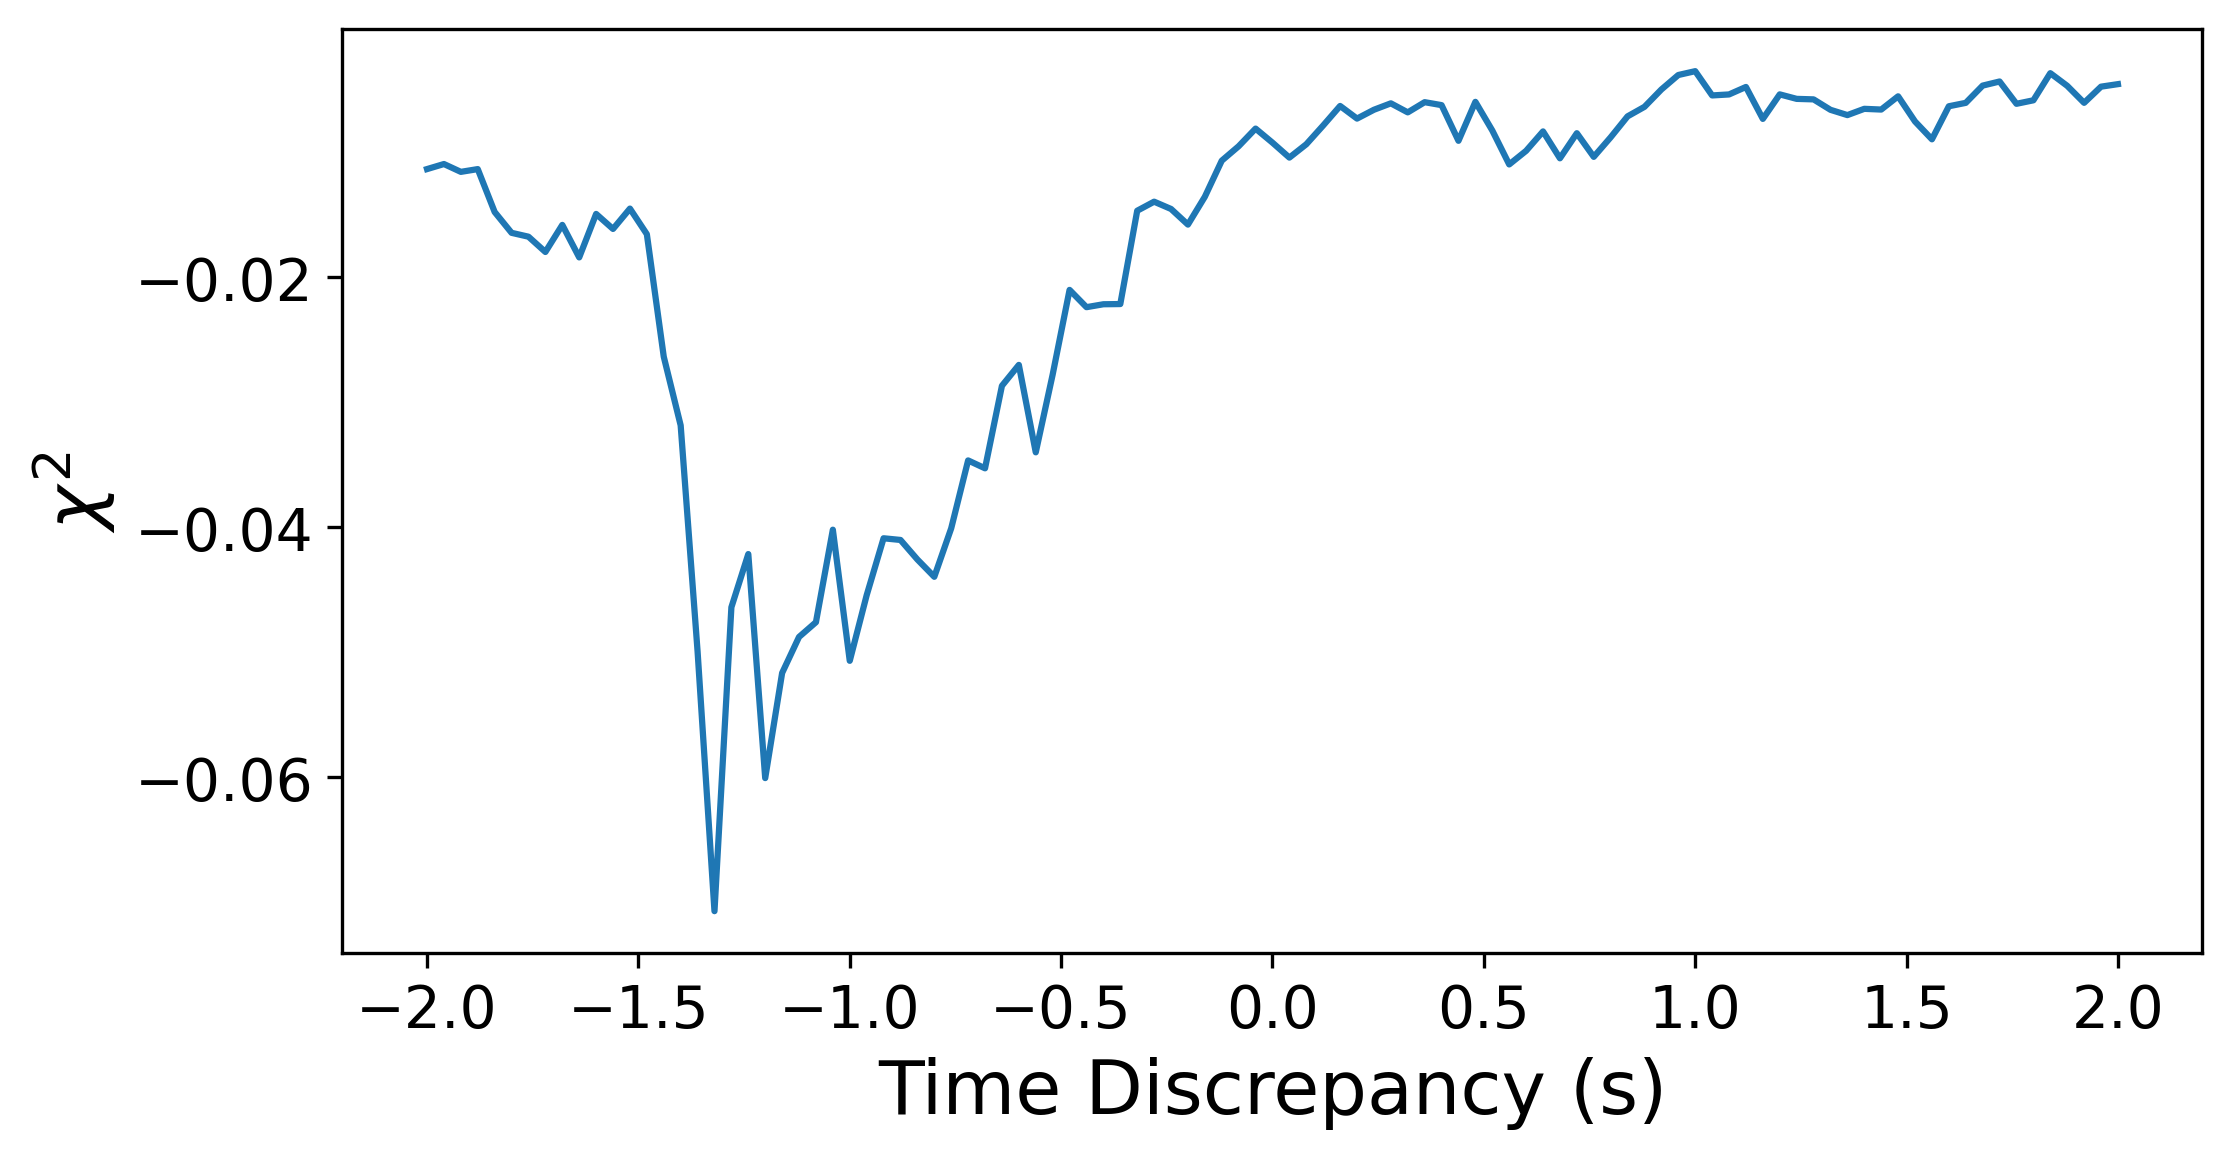

In [26]:
#once without cutting to see if it sucks (it should)
offsets, chisqs, fig = cost_curve(
                            -2, 
                            2, 
                            101, 
                            batch_start_ts, 
                            batch_end_ts-2, 
                            data_slice, 
                            ant_idxs, 
                            ant_coords, 
                            freq, 
                            satID, 
                            include_fig=True
                            )

In [75]:
#extract guess offset
guess_offset = offsets[np.argmin(chisqs)]
print(guess_offset) 

-1.2


nspec total 332800
nspec 331878
time for objective compute: 0.5952558517456055
offset -1.2 chisq -0.06927405075029185


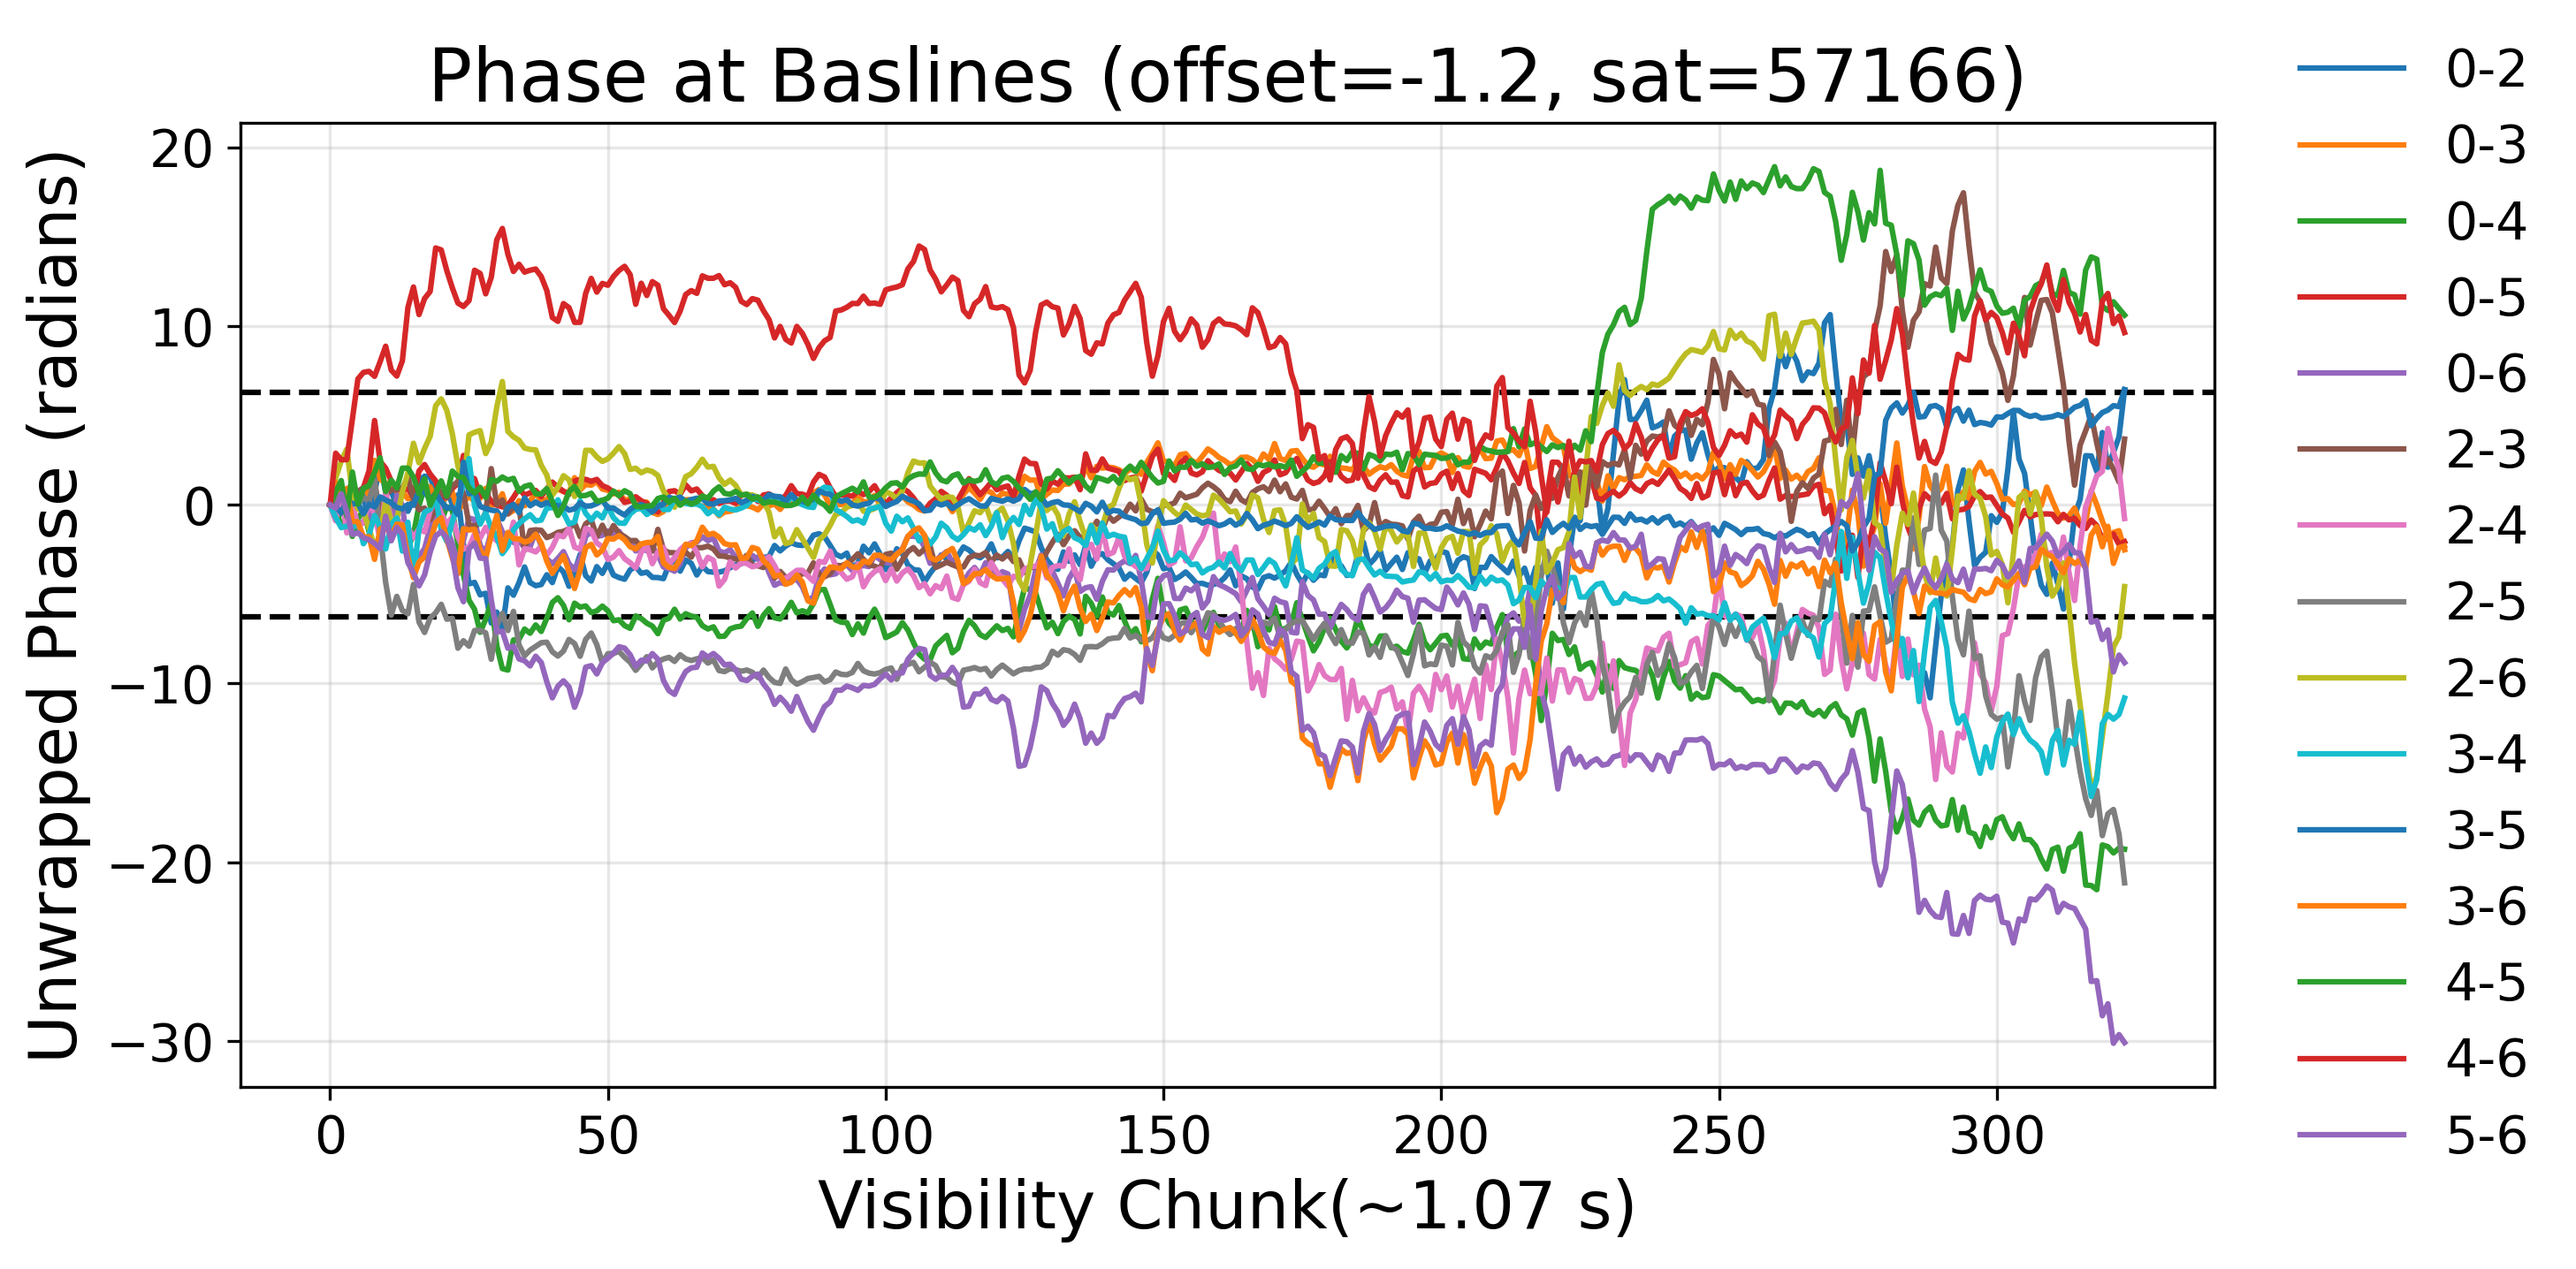

In [76]:
#check what it gives you for guess with uncut
chisq = objective_times(guess_offset,
                        batch_start_ts,
                        batch_end_ts-2,
                        data_slice,
                        ant_idxs,
                        ant_coords,
                        freq,
                        satID,
                        plot=True)


----ITERATION 0-----
nspec total 272800
nspec 130734
time for objective compute: 0.7018430233001709
offset -2.0 chisq -0.03976931494908834

----ITERATION 1-----
nspec total 272800
nspec 130734
time for objective compute: 0.7670717239379883
offset -1.96 chisq -0.04211762177274346

----ITERATION 2-----
nspec total 272800
nspec 130734
time for objective compute: 0.7409279346466064
offset -1.92 chisq -0.04386639901549311

----ITERATION 3-----
nspec total 272800
nspec 130734
time for objective compute: 0.7591946125030518
offset -1.88 chisq -0.04494368185423609

----ITERATION 4-----
nspec total 272800
nspec 130734
time for objective compute: 0.7487099170684814
offset -1.84 chisq -0.05128035620367758

----ITERATION 5-----
nspec total 272800
nspec 130734
time for objective compute: 0.7328541278839111
offset -1.8 chisq -0.05629238299398385

----ITERATION 6-----
nspec total 272800
nspec 130734
time for objective compute: 0.7325601577758789
offset -1.76 chisq -0.052792183827188796

----ITERATION

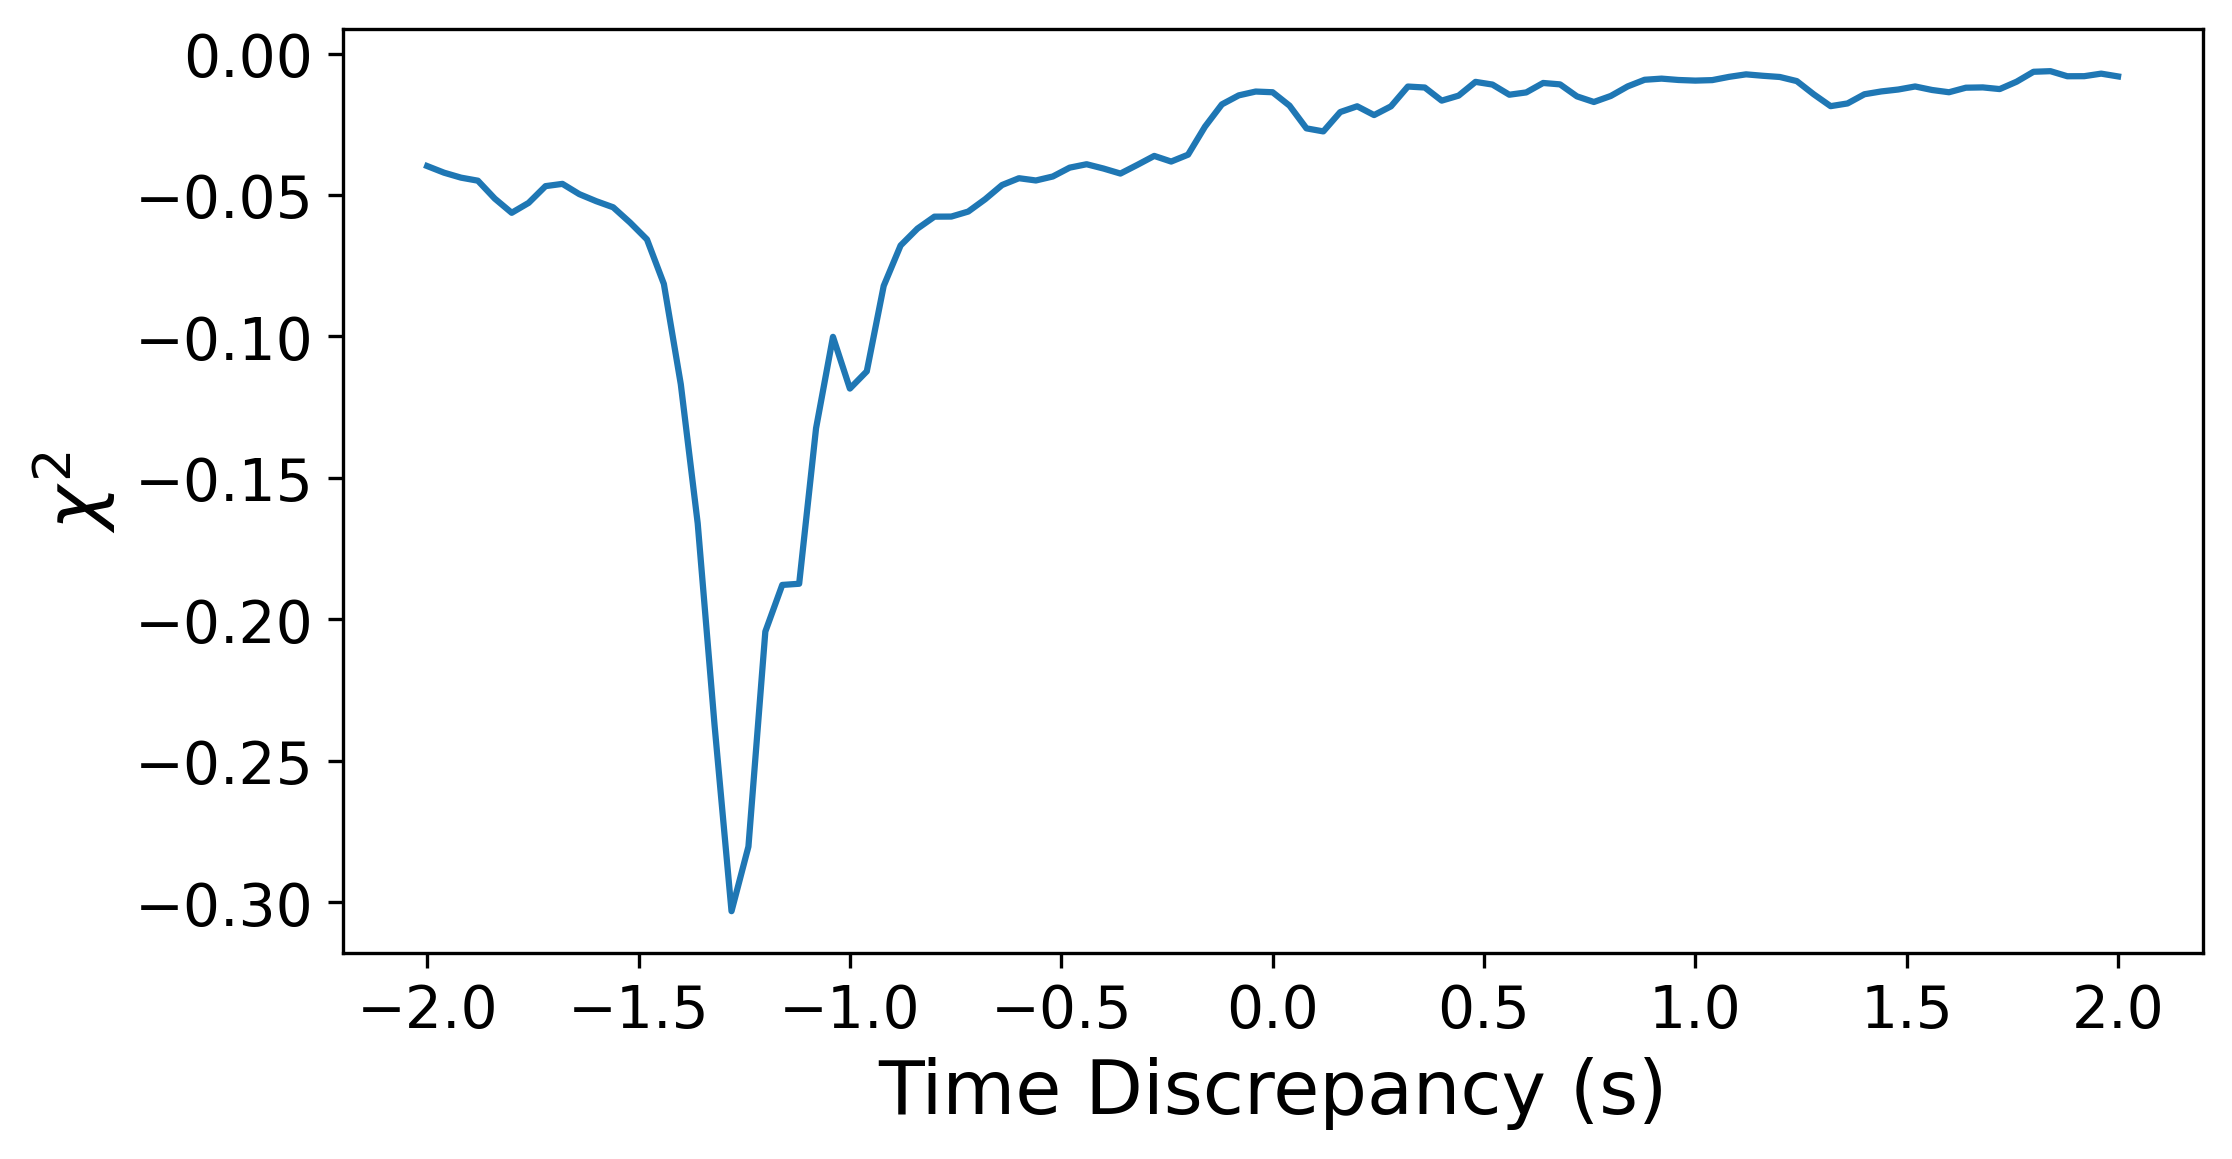

In [27]:
#get cost curve when cutting junk at start of pulse
offsets, chisqs, fig = cost_curve(-2, 
                                    2, 
                                    101, 
                                    pulse_start_ts, 
                                    pulse_end_ts, 
                                    data_slice_cut,
                                    ant_idxs, 
                                    ant_coords, 
                                    freq, 
                                    satID,
                                    include_fig=True)

In [28]:
#extract guess offset
guess_offset = offsets[np.argmin(chisqs)]
guess_offset = np.round(guess_offset, decimals = 4)
print(guess_offset) 

-1.28


nspec total 272800
nspec 130734
time for objective compute: 0.8019874095916748
offset -1.28 chisq -0.3030984499830915


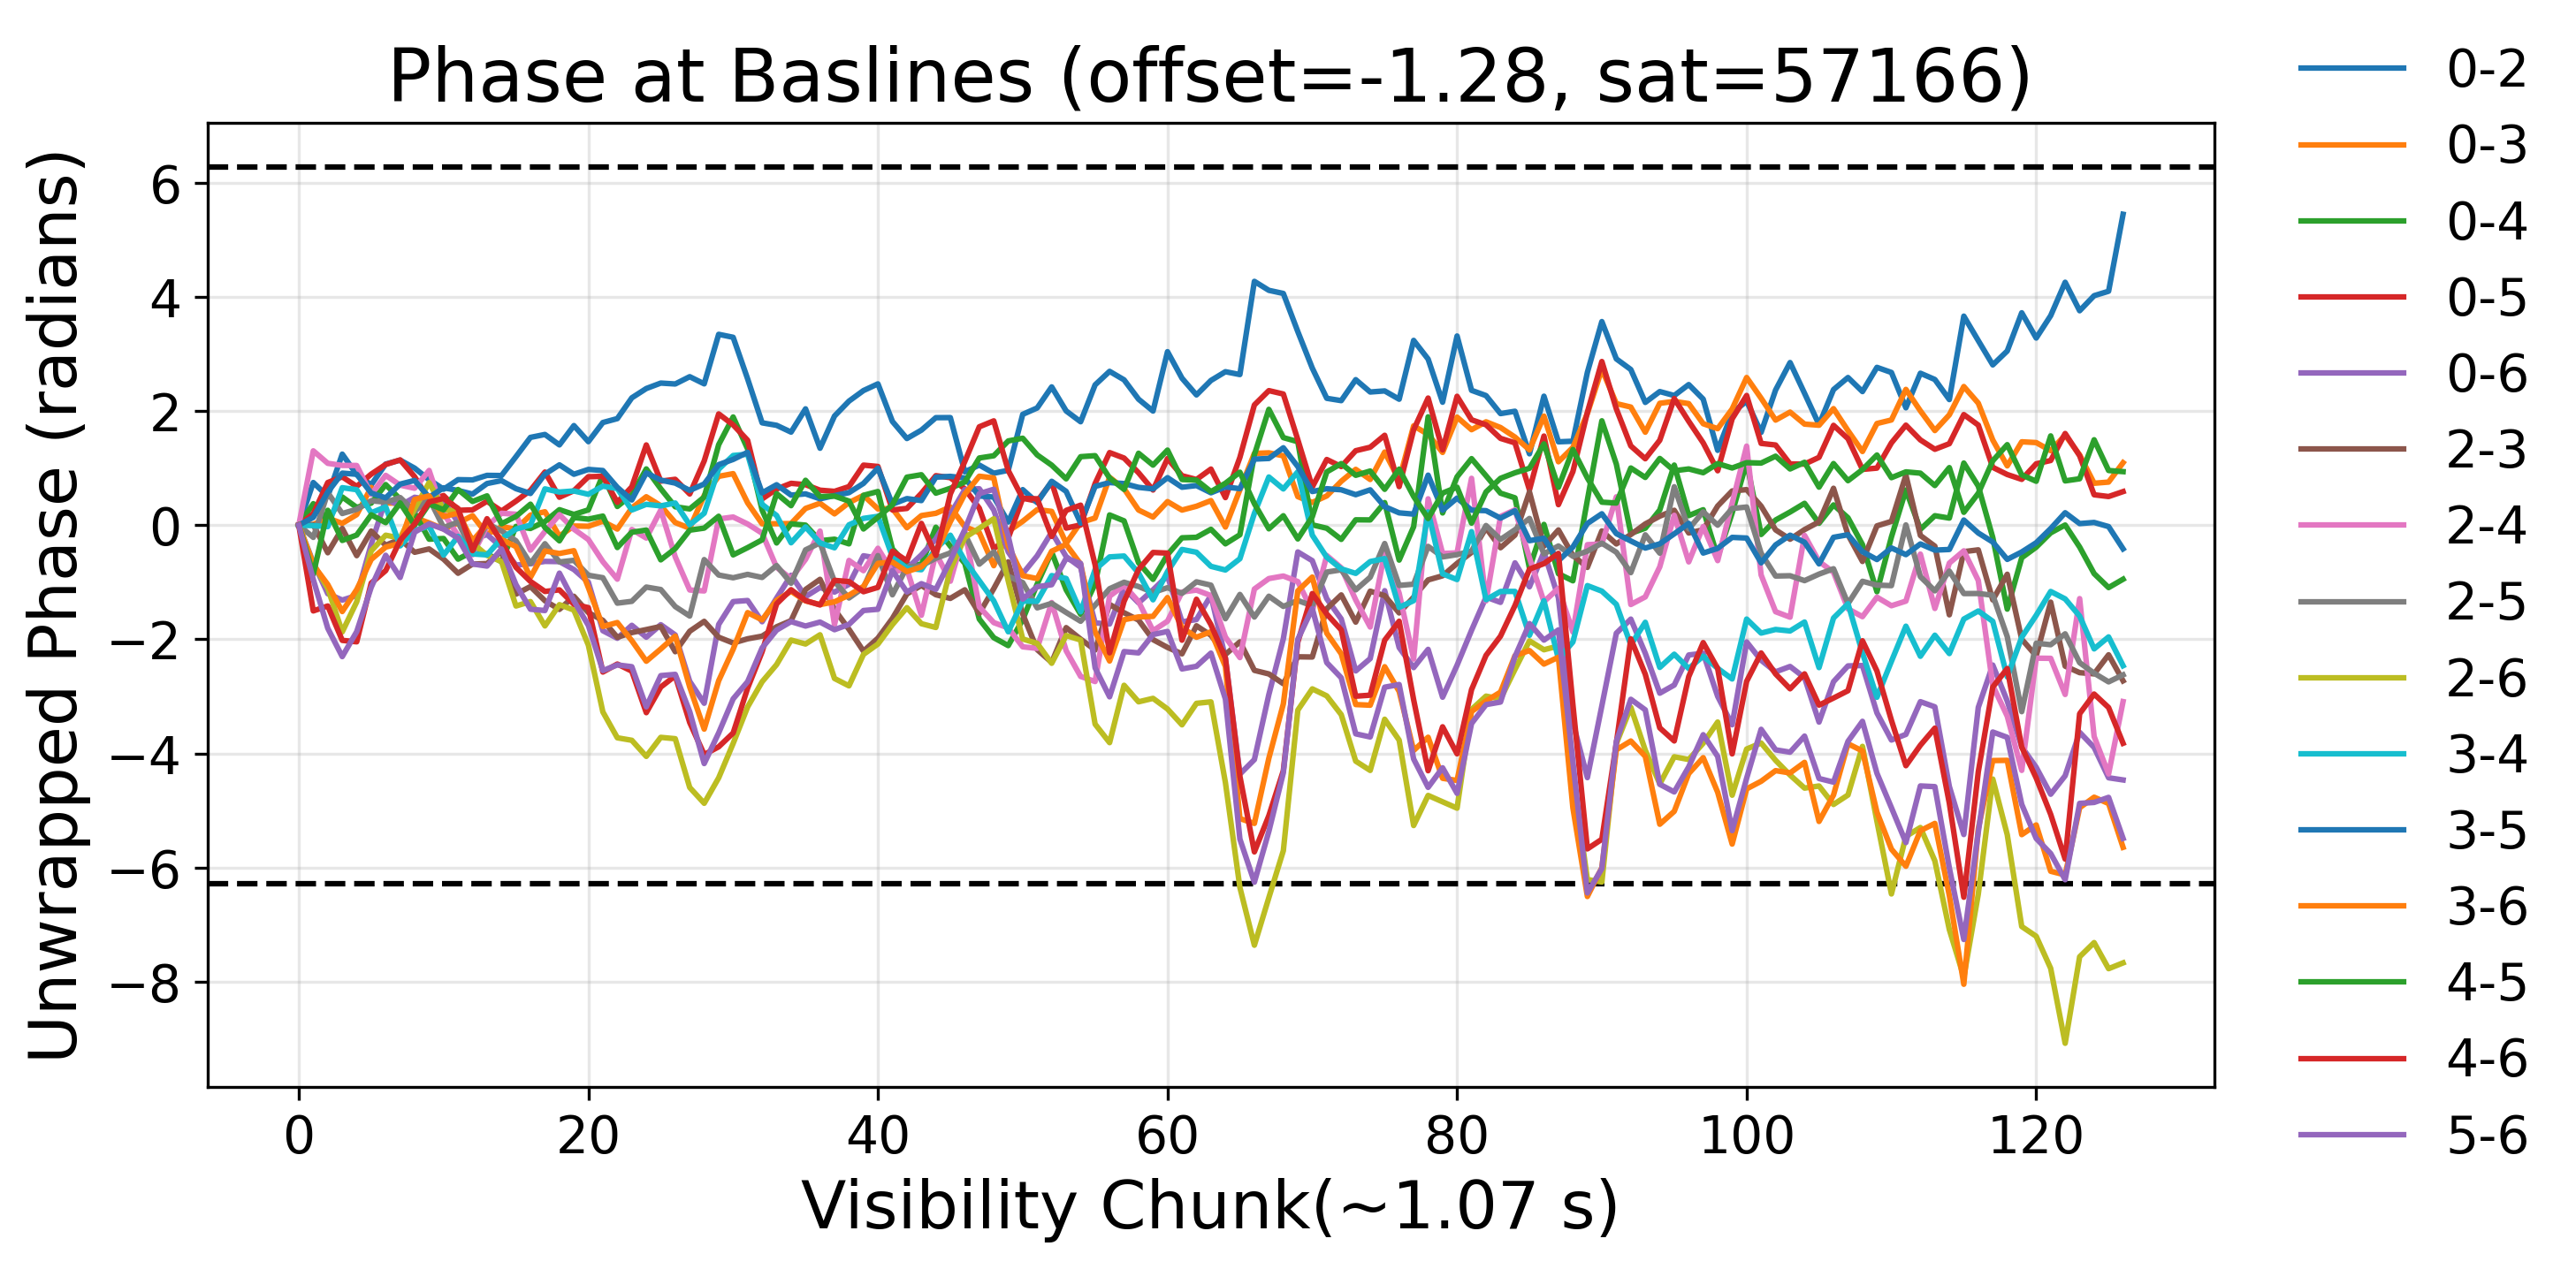

In [29]:
#plot the guess offset with the cut pulse
chisq = objective_times(guess_offset,
                        pulse_start_ts,
                        pulse_end_ts,
                        data_slice_cut,
                        ant_idxs,
                        ant_coords,
                        freq,
                        satID,
                        plot=True)

In [30]:
#determine minimum with the (good) cut pulse

result = minimize(objective_times, 
        guess_offset,
        args=(pulse_start_ts, 
                pulse_end_ts, 
                data_slice_cut, 
                ant_idxs, 
                ant_coords, 
                freq, 
                satID,
                False,
                bb_spectrum_T,
                osamp,
                acclen), 
        method='Nelder-Mead',
        tol=1e-12)

nspec total 272800
nspec 130734
time for objective compute: 0.7444491386413574
offset -1.28 chisq -0.3030984499830915
nspec total 272800
nspec 130734
time for objective compute: 0.763075590133667
offset -1.344 chisq -0.19157167440376976
nspec total 272800
nspec 130734
time for objective compute: 0.7715728282928467
offset -1.216 chisq -0.23215284527008764
nspec total 272800
nspec 130734
time for objective compute: 0.7614731788635254
offset -1.2479999999999998 chisq -0.29297120987974096
nspec total 272800
nspec 130734
time for objective compute: 0.7677345275878906
offset -1.3120000000000003 chisq -0.2538130723269984
nspec total 272800
nspec 130734
time for objective compute: 0.7769501209259033
offset -1.2639999999999998 chisq -0.30696407080777455
nspec total 272800
nspec 130734
time for objective compute: 0.7763895988464355
offset -1.2479999999999996 chisq -0.29297120987974096
nspec total 272800
nspec 130734
time for objective compute: 0.7762033939361572
offset -1.2719999999999998 chisq 

In [31]:
#obtain fitted value
fitted_offset = result.x[0]
print(fitted_offset)

-1.2685624999999998


In [ ]:
#TEST CASE FOR FIRST PULSE (57166 at 1753216650)
#channel 140
#cutting 60k spectra from start
#150s cut at end
#should give offset of -1.2685624999999998
#or something close at least


----ITERATION 0-----
nspec total 181472
nspec 172859


time for objective compute: 0.7529082298278809
offset 0.09999999999999998 chisq -0.07424768170197167

----ITERATION 1-----
nspec total 181472
nspec 172859
time for objective compute: 0.7927765846252441
offset 0.10399999999999998 chisq -0.07516557128568427

----ITERATION 2-----
nspec total 181472
nspec 172859
time for objective compute: 0.7887122631072998
offset 0.10799999999999998 chisq -0.07611455485278373

----ITERATION 3-----
nspec total 181472
nspec 172859
time for objective compute: 0.7533485889434814
offset 0.11199999999999997 chisq -0.07710521687661517

----ITERATION 4-----
nspec total 181472
nspec 172859
time for objective compute: 0.6881475448608398
offset 0.11599999999999998 chisq -0.07814940766242734

----ITERATION 5-----
nspec total 181472
nspec 172859
time for objective compute: 0.6958041191101074
offset 0.11999999999999998 chisq -0.07922701318393713

----ITERATION 6-----
nspec total 181472
nspec 172859
time for objective compute: 0.738609790802002
offset 0.123999999999999

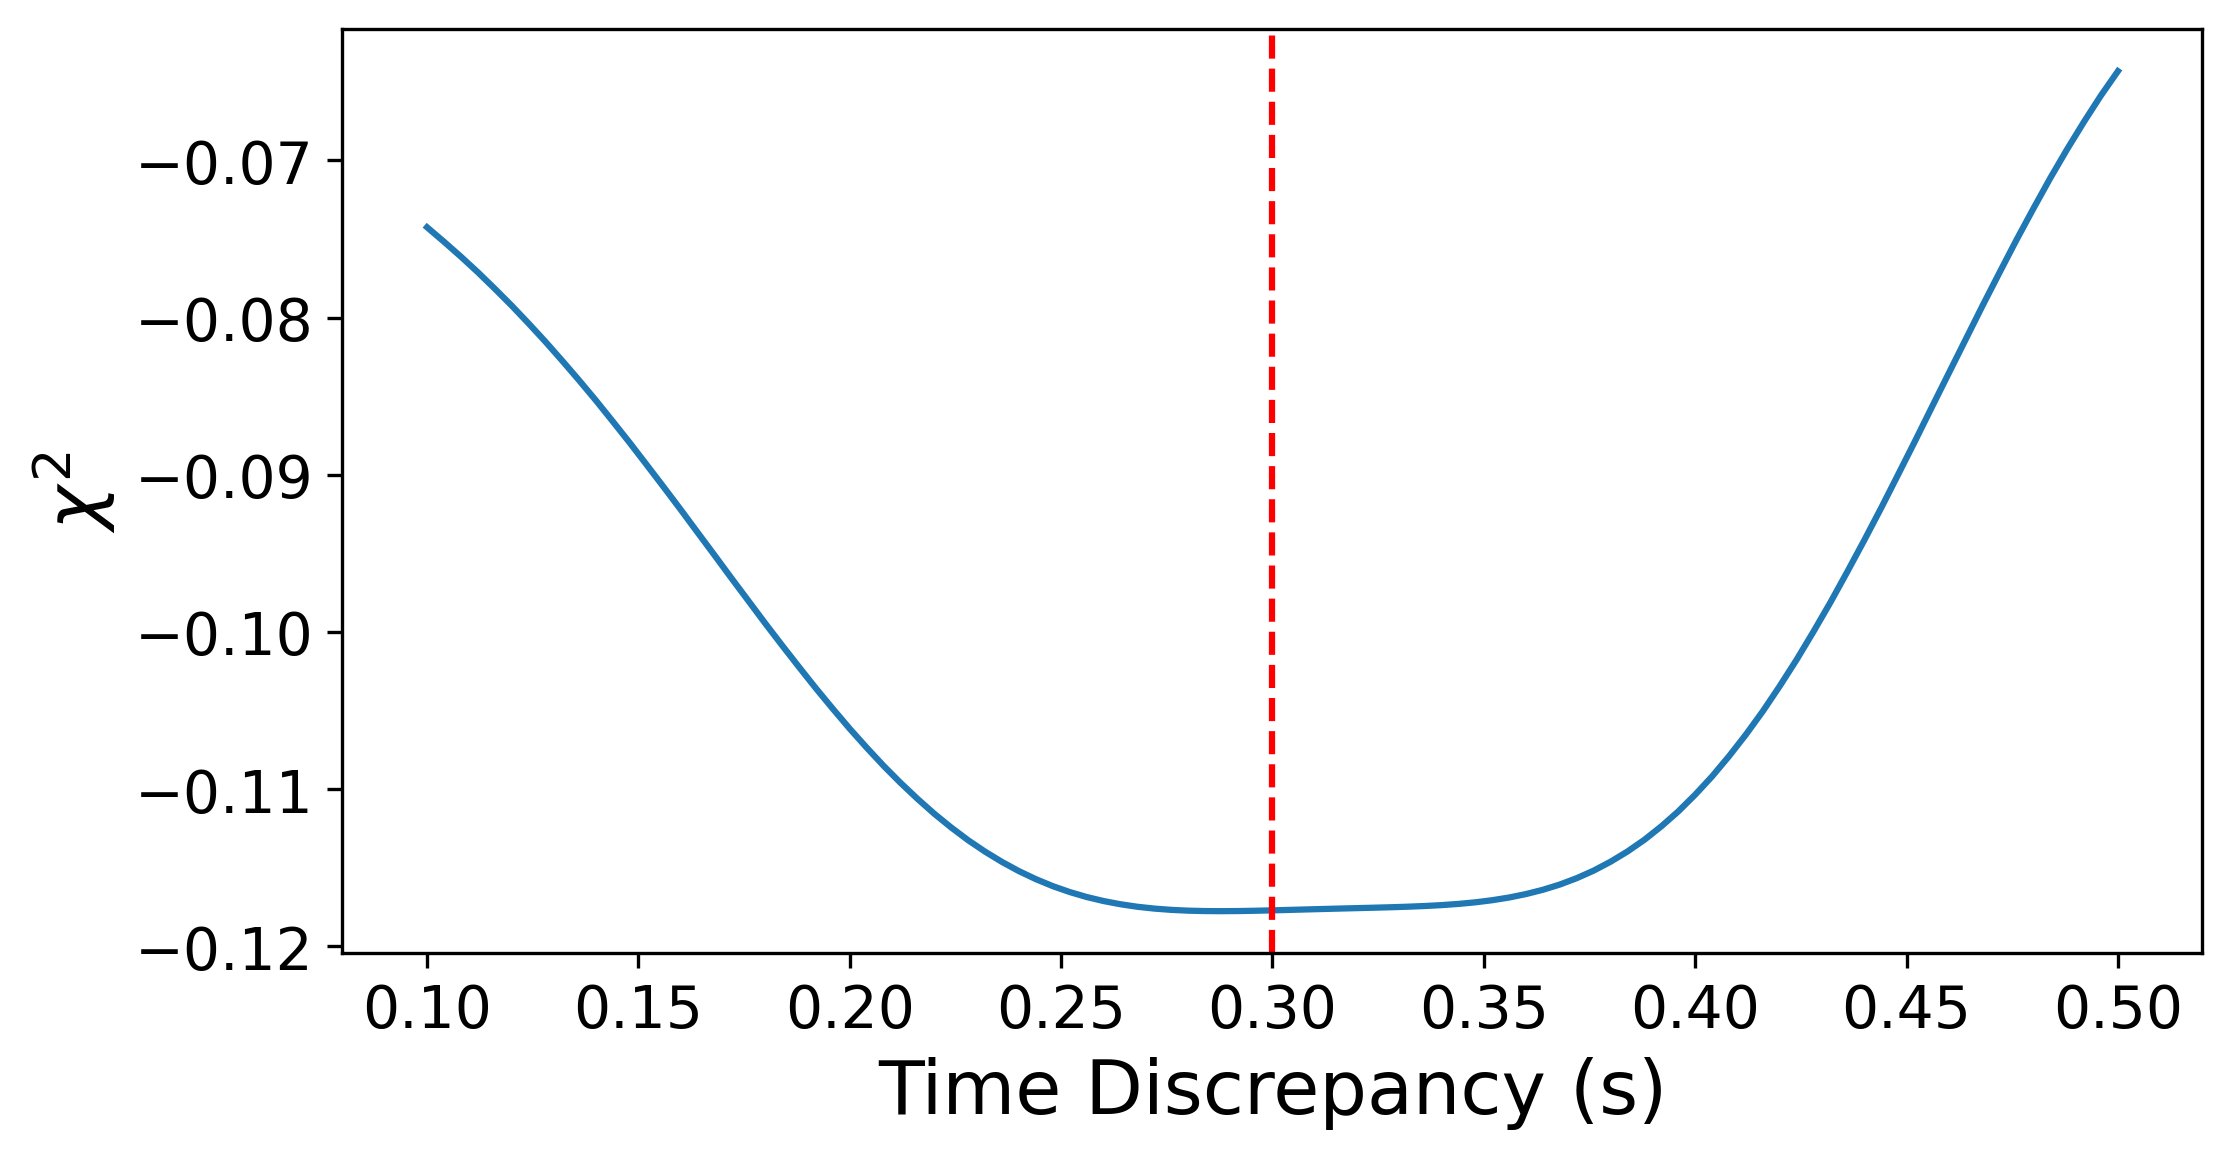

In [34]:
#plot around fitted value for visual sanity check (0.2s ball)
#rounded_fit = np.round(fitted_offset, decimals = 2)
#print(rounded_fit)
rounded_fit = 0.3
offsets_closer, chisqs_closer, fig_closer = cost_curve(rounded_fit-0.2, 
                                    rounded_fit+0.2, 
                                    101, 
                                    pulse_start_ts, 
                                    pulse_end_ts, 
                                    data_slice_cut, 
                                    ant_idxs, 
                                    ant_coords, 
                                    freq, 
                                    satID,
                                    include_fig=True, 
                                    vline=rounded_fit) ######replace with fitted_offset later

In [24]:
def polisher(
    t_start, 
    t_end, 
    data_slice, 
    ant_idxs, 
    ant_coords, 
    freq, 
    satID,
    guess_linspace=(-2, 2, 101),
    bb_spectrum_T=4096/250e6,
    osamp=64,
    acclen=1024
):


    offsets, chisqs, fig = cost_curve(guess_linspace[0], 
                                        guess_linspace[1], 
                                        guess_linspace[2], 
                                        t_start, 
                                        t_end, 
                                        data_slice, 
                                        ant_idxs, 
                                        ant_coords, 
                                        freq, 
                                        satID, 
                                        bb_spectrum_T=bb_spectrum_T, 
                                        osamp=osamp,
                                        include_fig=True)

    guess_offset = offsets[np.argmin(chisqs)]

    result = minimize(objective_times, 
        guess_offset,
        args=(t_start, 
                t_end, 
                data_slice, 
                ant_idxs, 
                ant_coords, 
                freq, 
                satID,
                False,
                bb_spectrum_T,
                osamp,
                acclen), 
        method='Nelder-Mead',
        tol=1e-12)

    fitted_offset = result.x[0]

    fitted = objective_times(fitted_offset,
                            pulse_start_ts,
                            pulse_end_ts,
                            data_slice,
                            ant_idxs,
                            ant_coords,
                            freq,
                            satID,
                            plot=True,
                            bb_spectrum_T=bb_spectrum_T,
                            osamp=osamp)

    return fitted_offset


----ITERATION 0-----
nspec total 181472
nspec 172859
time for objective compute: 0.7989628314971924
offset -2.0 chisq -0.009978570522424866

----ITERATION 1-----
nspec total 181472
nspec 172859
time for objective compute: 0.8159160614013672
offset -1.96 chisq -0.010905937116372355

----ITERATION 2-----
nspec total 181472
nspec 172859
time for objective compute: 0.7758846282958984
offset -1.92 chisq -0.012336624218233925

----ITERATION 3-----
nspec total 181472
nspec 172859
time for objective compute: 0.7694680690765381
offset -1.88 chisq -0.013489578425849042

----ITERATION 4-----
nspec total 181472
nspec 172859
time for objective compute: 0.7262861728668213
offset -1.84 chisq -0.014706196595020914

----ITERATION 5-----
nspec total 181472
nspec 172859
time for objective compute: 0.7631731033325195
offset -1.8 chisq -0.016199210067680308

----ITERATION 6-----
nspec total 181472
nspec 172859
time for objective compute: 0.7771220207214355
offset -1.76 chisq -0.016806516459659943

----ITE

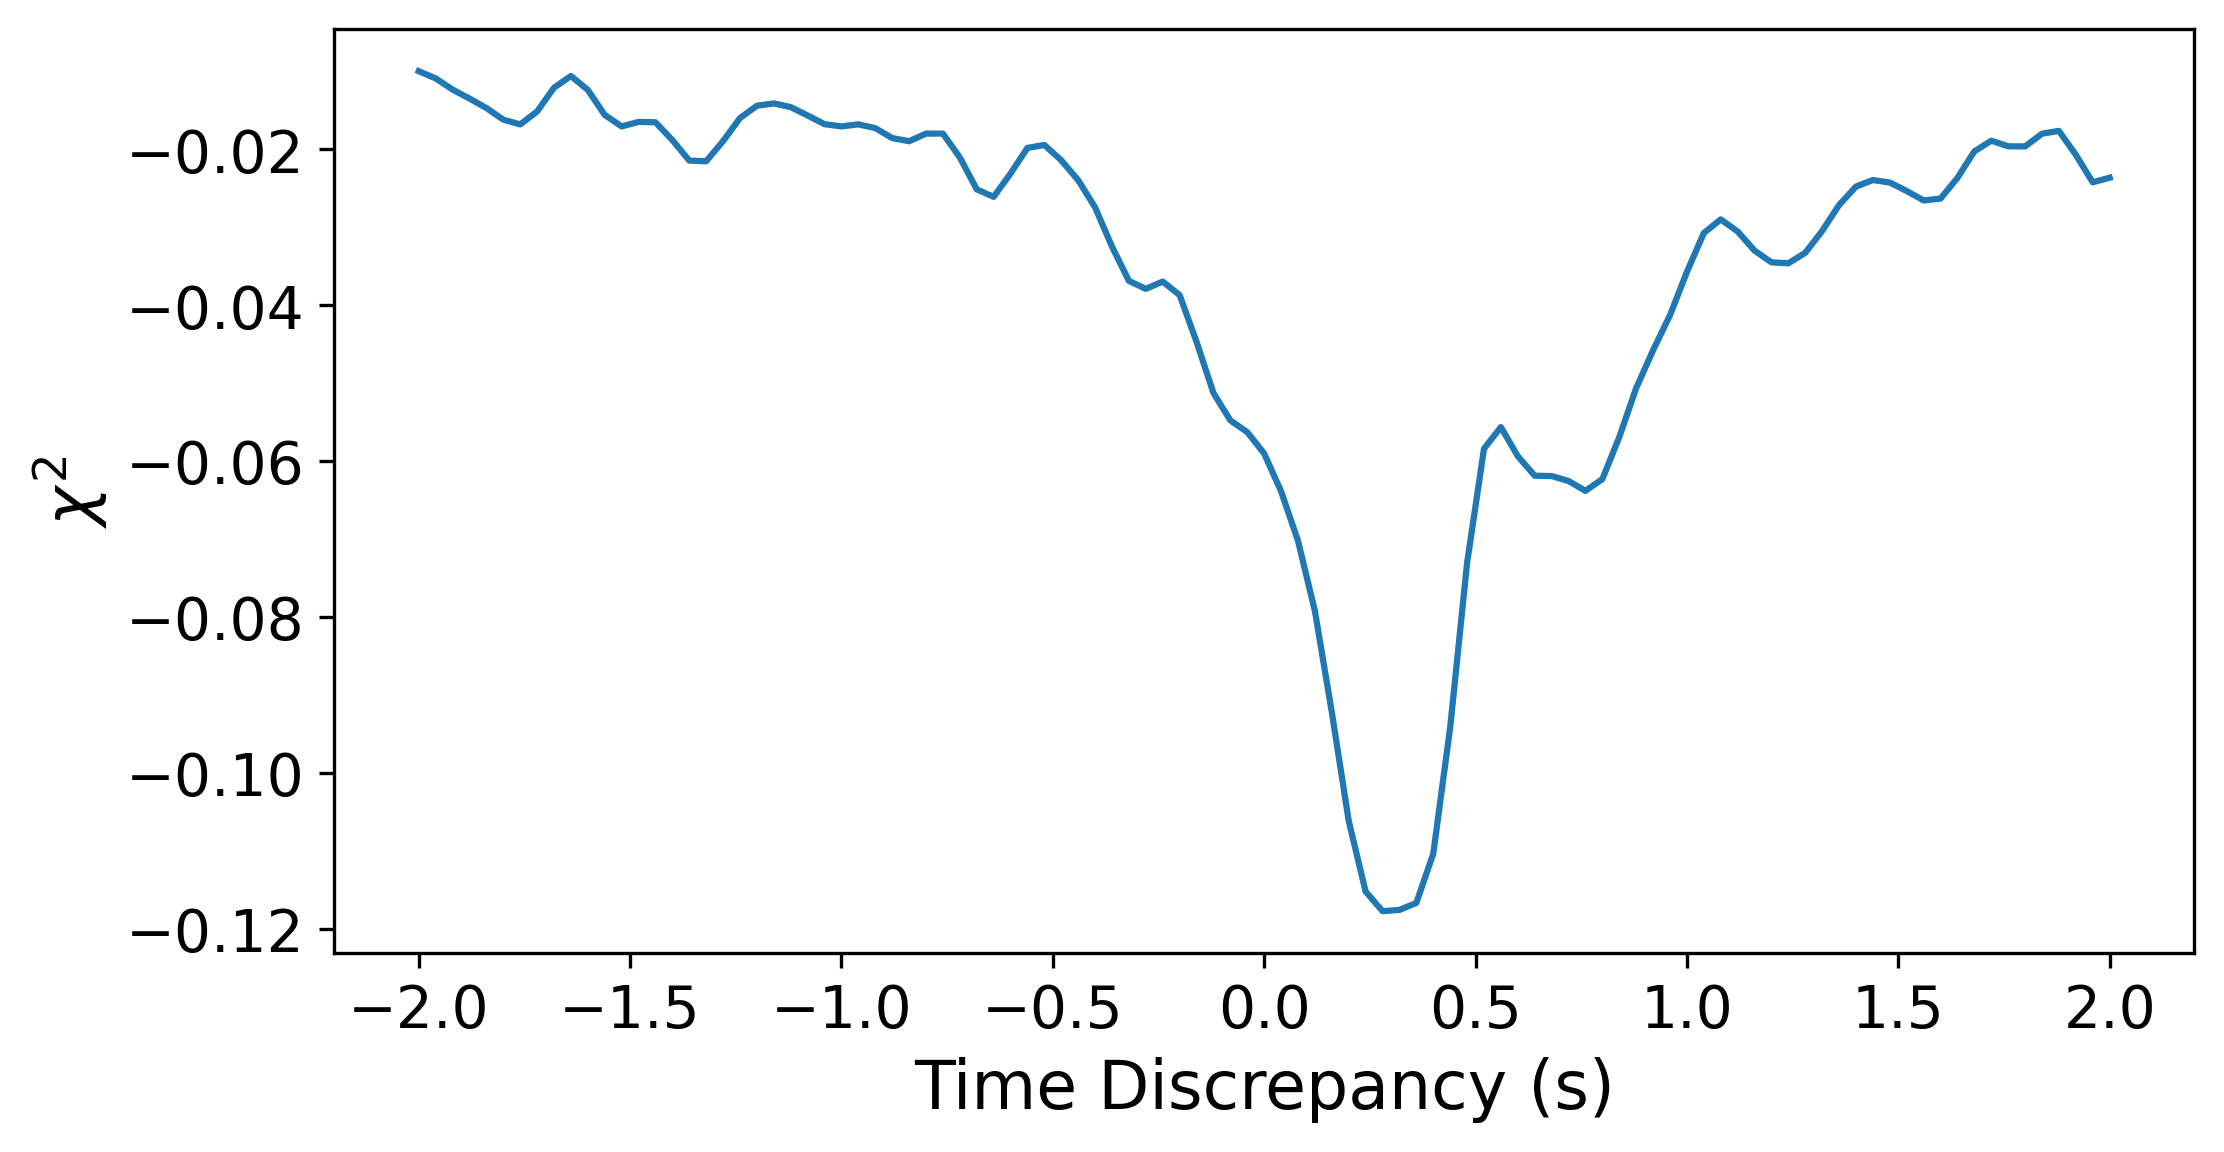

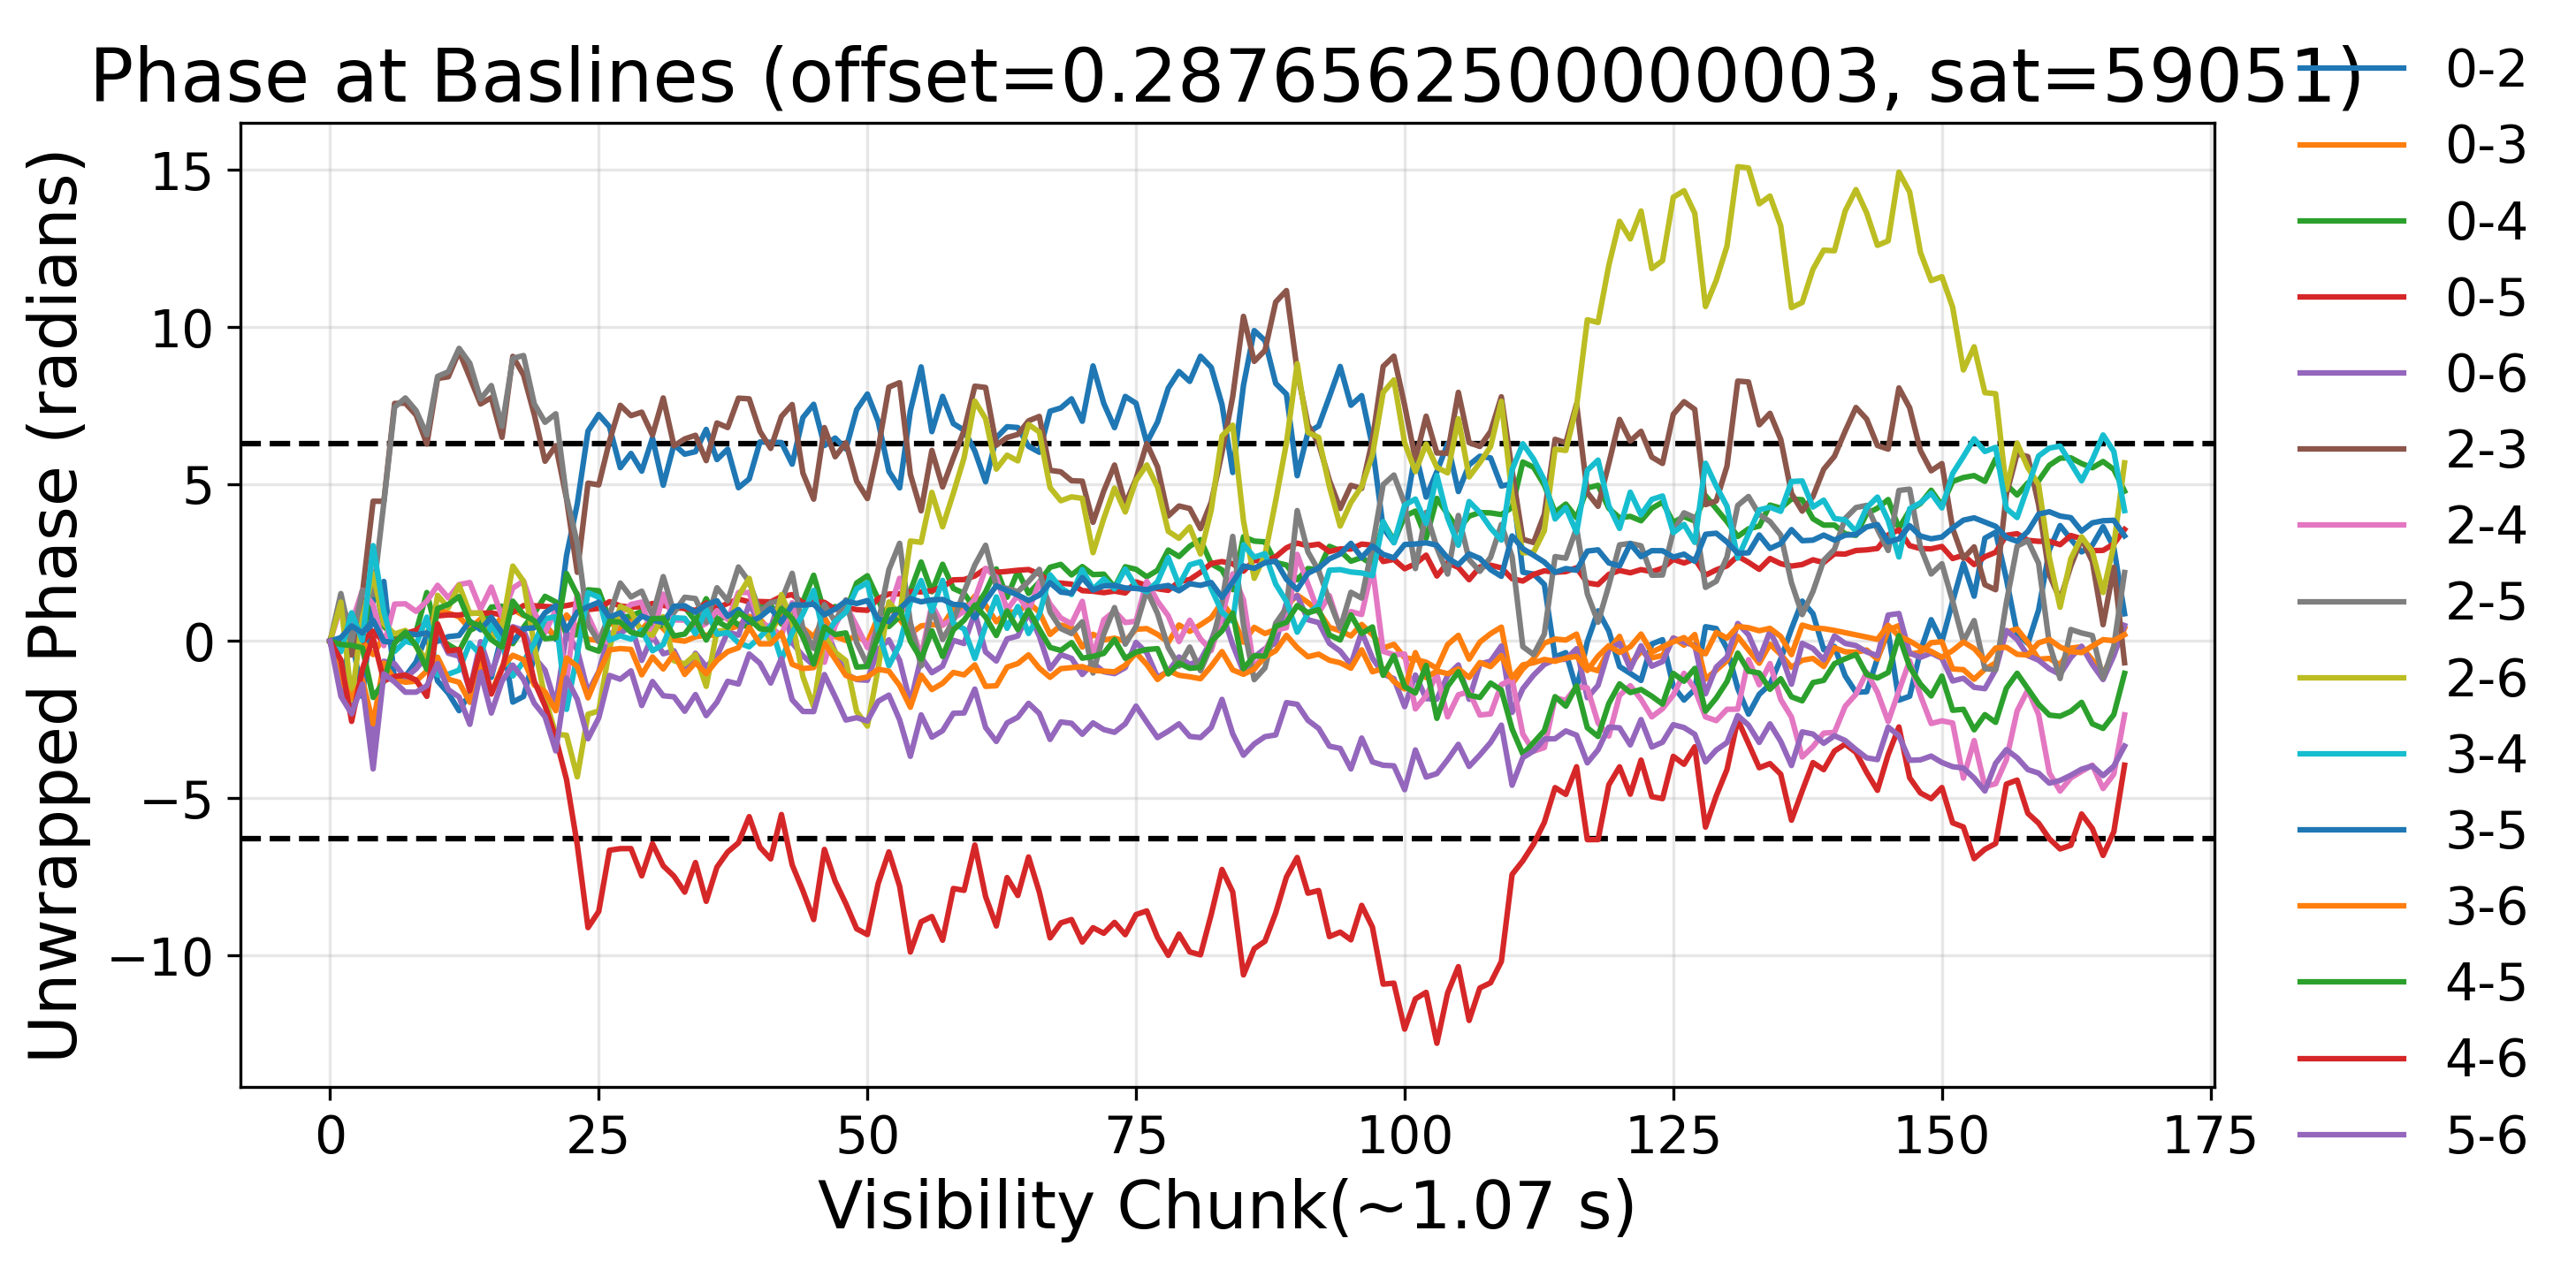

In [31]:
fitted_t = polisher(pulse_start_ts, 
                    pulse_end_ts, 
                    data_slice_cut, 
                    ant_idxs, 
                    ant_coords, 
                    freq, 
                    satID,
                    guess_linspace=(-2, 2, 101))
print(fitted_t)